# Which contract should a household with no battery sign?

One question, asked three times, on the same Fluvius households the horizon study uses —
**`PER_GROUP` from each of the 8 groups** (plain, EV, HP, HP+EV, PV, PV+EV, PV+HP, PV+HP+EV),
full year, 15-minute intervals, **no battery anywhere in this notebook**. `PER_GROUP` is set in
section 0 and defaults to 5, i.e. 40 households; every table, chart and cache below follows it.

That last clause is what makes the question answerable at all. With no battery there is
**no dispatch decision**: the household imports exactly what it did not generate in the
interval it did not generate it, and exports the rest. There is nothing to optimize, no
MILP, no horizon — the annual bill is a pure function of the price list, and the answer
is simply the cheapest one. Which also makes it the reading to take *before* any battery
result, because it separates two very differently-priced problems:

> **"this household is on the wrong contract"** — fixed by a phone call, worth up to
> 20 % of the bill · **"this household needs a battery"** — worth ~30 kWh of hardware

### The three chapters

| | who | export credited at | asks |
|---|---|---|---|
| **1** | the 20 households with **no PV** | — nothing to export | which plain supply list, billed under `si_dobava` |
| **2** | the 20 households **with PV** | the list's own `tip_odkupa` | which *samooskrba* list, billed under `si_samooskrba` |
| **3** | the same 20 **with PV** | **zero** | the same lists for a household that may not sell |
| **4** | best 3 and worst 3 contracts, PV only | both | what the right to sell the surplus is actually worth |

Chapters 2 and 3 are the same computation with one term changed, which is the point: the
import side, the fixed charges and the excess-power charge are held identical, so
everything that moves between them is the buyback. Chapter 4 takes the **best 3 and the worst 3**
contracts and shows each of them under both regimes, so the value of the right to sell is read off
the same row rather than by flipping between two rankings.

### A contract is a price list *and* a meter

A Slovenian *tarifni* price list usually publishes **three** supplier rates: `VT` and `MT` for a
two-tariff meter, and a single `ET` rate for a one-tariff meter. They are alternative products on
the same cenik, and the household picks one when it picks its meter — so a comparison that
silently takes one of them is comparing suppliers on a choice the customer actually gets to make.

Every row in this notebook is therefore a **price option**: a list plus, where the supplier
publishes both, which variant is being billed.

| in the tables | what it means |
|---|---|
| `… [2T]` | two-tariff meter, billed `VT` in the high window and `MT` otherwise |
| `… [1T]` | single-tariff meter, billed the flat `ET` rate around the clock |
| no suffix | the list offers no such choice — a 4-block (*aktivni*) or spot-linked (*dinamični*) list, or a *tarifni* list that publishes only one of the two |

The `Structure` column spells out the actual rates behind each, so no table leaves it implicit.
Two asymmetries worth noticing before chapter 2: **`GEN-I Samo Redni` is 1T only** — GEN-I sells no
two-tariff *samooskrba* product at all — while **`Petrol Samooskrba` publishes both**, so it is the
one samooskrba list that appears twice. On the no-PV side of chapter 1 most lists appear twice,
which is why 15 price lists become 25 options.

### What "no PV" and "with PV" mean in this data

The Fluvius columns are **meter registers**, not gross load and gross production:
`Consumption_Volume_kWh` is grid offtake and `Feed_In_Volume_kWh` is grid injection, and
they are very nearly mutually exclusive — both non-zero in only 9.7 % of the 702 720
PV-household intervals (2.4 % to 14.2 % per household), which is the 15-minute aggregation
of a meter that netted at a finer resolution. So the roof's
**self-consumption has already been netted away before the data starts**, and no contract
term in this notebook can reach it. What every chapter prices is the *residual*: the
import that survived the roof, and the surplus it could not absorb. That is exactly what
a bill is measured on — but it means chapter 3 removes the value of the **surplus** only,
never the much larger saving the roof makes by displacing retail import in the first
place. A PV household here is not "a household that could go off-grid"; it is a
household whose meter shows 500–3 100 kWh/a going the other way.

### Runtime

Everything is cached to `Results/`, and every step is minutes rather than hours:

| chapter | cache | cost to recompute |
|---|---|---|
| 1 — no PV | `no_pv_tariff_comparison_pg{PER_GROUP}.csv` | ~50 s at `PER_GROUP = 5` |
| 2 — PV, credited | `pv_tariff_comparison_buyback_pg{PER_GROUP}.csv` | ~30 s |
| 3 — PV, no sale | `pv_tariff_comparison_nosale_pg{PER_GROUP}.csv` | ~15 s (the per-interval rates are already cached) |

There is no MILP in this notebook and no batch to wait on. Set the `RUN_*` flag above a
chapter to recompute it — and note that **each sample size gets its own cache**: the file name
carries `PER_GROUP` and every row records it, so changing the setting recomputes into a new file
rather than overwriting the old one or averaging one sample as if it were another. Switching back
to a size already run costs nothing.

In [1]:
### Imports
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_rgb
from matplotlib.patches import Patch

import importlib
import Horizon_Comparison as hc
hc = importlib.reload(hc)
from Pricing_Functions import PAKETI

RESULTS_DIR = hc.RESULTS_DIR.parent          # Results/, where the three caches live


def cache_path(name, per_group):
    """Cache file for one chapter at one sample size.

    The sample size is in the FILENAME, not just in a column: two settings then
    coexist instead of overwriting each other, so switching PER_GROUP back and
    forth costs nothing after the first run of each. The column is still checked
    on read -- the name says what a file should be, the column says what it is.
    """
    return RESULTS_DIR / f"{name}_pg{int(per_group)}.csv"
print(f"Horizon_Comparison loaded: {len(hc.consumer_price_lists())} plain supply lists, "
      f"{len(hc.prosumer_price_lists())} samooskrba lists.")

Horizon_Comparison loaded: 25 plain supply lists, 7 samooskrba lists.


## 0. What the bill is made of, and the one thing a contract cannot change

The study parameters live in `Horizon_Comparison.py`, the same module the horizon study
reads, so the two notebooks cannot drift apart on the household sample, the pricing
regime or the agreed billing power.

**`PER_GROUP` is the one knob here.** It sets how many households are drawn from each of the 8
Fluvius groups, and it is the same argument `hc.study_units` takes, so the sample stays a balanced
panel at any setting: raising it never changes the mix of household types, only how many of each.
The default 5 gives 40 households (20 no-PV, 20 with PV). Drop it to 1 or 2 for a fast pass while
editing, raise it toward `hc.HOUSEHOLDS_PER_GROUP` for the published run. Each comparison records
its own `Per_Group` on every row, so a cache written at one setting is recomputed rather than
misread at another.

The bill has three parts, and **only the first is competitive**:

| part | what it is | can a contract change it? |
|---|---|---|
| **energy** | supplier price + `omrežnina` energy rate per block + levies, ×1.22 VAT, **minus** the buyback credit on the surplus | yes — this is the whole spread between suppliers |
| **fixed** | `omrežnina` power rate × **agreed** power + OVE/SPTE + the supplier's monthly fee | only through the monthly fee and the agreed power, not the tariff structure |
| **excess power** | `omrežnina` power rate × (monthly peak − agreed power) × 1.05 | **no** — identical on every list, and identical in every chapter below |

The last two both move with the **agreed billing power** (*dogovorjena obračunska moč*),
which is modelled here as a household that manages the figure itself: every month it
agrees exactly the per-block peak the previous month realized, with no regulatory floor
and no connection-power ceiling, and only the Akt's monotonicity rule
(`P1 ≤ P2 ≤ P3 ≤ P4 ≤ P5`) applied. The leading month has no predecessor, so it is
bootstrapped from the last complete month of the same dataset
(`hc.AGREED_POWER_BOOTSTRAP = "cyclic"`). `MILP_horizon_comparison` section 1b has the
full argument for that rule and the alternatives; nothing about it differs here.

Two consequences worth holding on to before reading any table:

* **The excess-power charge is the same number on every list**, because it is a network
  charge, not a supply one. It is therefore *never* a reason to prefer one contract —
  it is the line a battery moves, which is why it belongs in this notebook only as a
  constant to be recognized and set aside.
* **Choosing your own agreed power is what makes that charge payable at all.** Since
  24. 4. 2025 a household up to 43 kW that leaves its assigned agreed power alone is
  permanently exempt. The household modelled here is not, and pays 1.05 × the block
  power rate on the exceedance in 2026.

In [2]:
PER_GROUP = 5        # households drawn from EACH Fluvius group; 1-2 for a fast pass

UNITS = hc.study_units(per_group=PER_GROUP)
NO_PV_UNITS = hc.study_units(hc.NO_PV_GROUPS, PER_GROUP)
PV_UNITS = hc.study_units(hc.PV_GROUPS, PER_GROUP)

print(f"households         : {PER_GROUP} per group = {len(UNITS)} units, no battery")
print(f"   no PV           : {len(NO_PV_UNITS)} units  "
      f"({', '.join(hc.NO_PV_GROUPS)})")
print(f"   with PV         : {len(PV_UNITS)} units  "
      f"({', '.join(hc.PV_GROUPS)})")
print(f"pricing regime     : {hc.PRICING_REFERENCE_YEAR}")
print(f"   no PV           : scheme {hc.CONSUMER_SCHEME} -- a plain supply contract")
print(f"   with PV         : scheme {hc.PROSUMER_SCHEME} -- netting INSIDE the 15-min "
      f"interval, then the surplus is credited")
print(f"agreed power       : {hc.AGREED_POWER_TAG}, leading month "
      f"{hc.AGREED_POWER_BOOTSTRAP!r}; identical in every chapter")
print(f"peak reset         : every {hc.PEAK_RESET_MONTHS} month(s), tag "
      f"{hc.PEAK_RESET_TAG!r} -- the excess-power charge is billed monthly")

# One row per price OPTION -- a list, plus which metering variant it is billed
# on where the supplier publishes both. `Structure` is the actual supplier rate,
# so which variant a row uses is never left to be inferred from the suffix.
consumer_options = hc.consumer_price_lists()
prosumer_options = hc.prosumer_price_lists()
n_consumer_lists = len({hc.option_base_id(o) for o in consumer_options})
n_prosumer_lists = len({hc.option_base_id(o) for o in prosumer_options})

print(f"\nplain supply options (chapter 1): {len(consumer_options)} "
      f"from {n_consumer_lists} price lists")
for o in consumer_options:
    p = PAKETI[hc.option_base_id(o)]
    print(f"   {hc.option_label(o):26s} {p.dobavitelj:18s} "
          f"{hc.tariff_structure_label(o):30s} fee {p.nadomestilo(True):.2f} EUR/mo")

print(f"\nsamooskrba options (chapters 2-4): {len(prosumer_options)} "
      f"from {n_prosumer_lists} price lists")
for o in prosumer_options:
    p = PAKETI[hc.option_base_id(o)]
    print(f"   {hc.option_label(o):26s} {p.dobavitelj:18s} "
          f"{hc.tariff_structure_label(o):30s} buyback: {hc.buyback_rate_label(o)}")

split = sorted({hc.option_base_id(o) for o in consumer_options + prosumer_options
                if hc.option_variant(o) != hc.VARIANT_NA})
print(f"\n{len(split)} lists publish BOTH a VT/MT and an ET rate and so appear twice: "
      f"{', '.join(split)}")
print("NET metering is left out on purpose: it is closed to new consents and settles "
      "once a year,\nso it is neither a list a household can choose into nor a bill a "
      "per-interval evaluator can write.")

households         : 5 per group = 40 units, no battery
   no PV           : 20 units  (Fluvius, Fluvius_EV, Fluvius_HP, Fluvius_HP_EV)
   with PV         : 20 units  (Fluvius_PV, Fluvius_PV_EV, Fluvius_PV_HP, Fluvius_PV_HP_EV)
pricing regime     : 2026
   no PV           : scheme si_dobava -- a plain supply contract
   with PV         : scheme si_samooskrba -- netting INSIDE the 15-min interval, then the surplus is credited
agreed power       : prev1m_cyclic_unbounded, leading month 'cyclic'; identical in every chapter
peak reset         : every 1 month(s), tag '1m' -- the excess-power charge is billed monthly

plain supply options (chapter 1): 25 from 15 price lists
   BISOL_DINAMICNI            BISOL Energija     dynamic: SIPX + 0.01300        fee 1.63 EUR/mo
   BISOL_DINAMICNI_PLUS       BISOL Energija     dynamic: SIPX + 0.01300        fee 3.26 EUR/mo
   BISOL_FIKSNI [2T]          BISOL Energija     2T: VT 0.12700 / MT 0.10700    fee 1.63 EUR/mo
   BISOL_FIKSNI [1T]          BISOL

In [3]:
### Shared chart styling
# ---------------------------------------------------------------------------
# What the colour channel means in THIS notebook, and it means only this:
#
#   hue      the export regime -- exports credited (blue) vs no sale (orange).
#            That is the comparison the notebook is about, so it is the one
#            thing allowed to own a categorical hue. Two slots, validated
#            all-pairs against the #fcfcfb surface: normal-vision OKLab dE
#            33.6 (floor 15), protan 24.7 / deutan 31.7 (target 8), contrast
#            4.30 and 3.12 (min 3.0). Both pass every check.
#   ramp     magnitude -- ONE hue, light -> dark. A ranked list of price lists
#            is a magnitude chart whose identity comes off the labelled axis,
#            so it never gets six competing hues.
#   shade    household type, a neutral ramp light -> dark by annual demand.
#
# Nothing here is ever the *rank* of a bar: a filter that drops a list must
# not repaint the survivors.
REGIME_COLOR = {"credited": "#2a78d6", "nosale": "#eb6834"}
REGIME_LABEL = {"credited": "presežke odkupi dobavitelj",
                "nosale":   "presežkov ni mogoče prodati"}
INK, INK_2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#8b8a84", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 10,
    "legend.frameon": False, "figure.dpi": 110,
})


def _mix(hex_color, other, t):
    """Blend two hex colours, t = share of `other`."""
    a = np.array(to_rgb(hex_color))
    b = np.array(to_rgb(other))
    return tuple((1.0 - t) * a + t * b)


def ramp(hex_color, name="ramp"):
    """Sequential ramp built from one hue: light -> dark, for magnitude panels."""
    return LinearSegmentedColormap.from_list(
        name, [SURFACE, _mix(hex_color, "#ffffff", 0.55), hex_color,
               _mix(hex_color, "#0b0b0b", 0.42)])


def group_label(dataset):
    """Household type as a chart label: the dataset prefix carries no meaning."""
    return "osnovni" if dataset == "Fluvius" else str(dataset).replace("Fluvius_", "")


def group_shades(groups, base=INK_2):
    """One neutral shade per household type, light -> dark by position.

    Household type is ORDERED (plain -> EV -> HP -> HP+EV, by annual demand), so
    it gets a single hue ramped rather than a categorical palette -- the
    categorical channel stays reserved for the export regime.
    """
    return [_mix(base, "#ffffff", t) for t in np.linspace(0.72, 0.05, len(groups))]


def short_list_name(option_id, variant=True):
    """Chart-axis label for one price OPTION.

    The metering variant is part of the identity, not a footnote: two rows that
    read "GEN-I Redni" and differ by 8 EUR/a would be unreadable, so a list that
    publishes both a VT/MT and an ET rate always carries its [2T]/[1T] tag.
    """
    base = hc.option_base_id(option_id)
    name = (base.replace("GENI_SAMO_", "GEN-I Samo ").replace("GENI_", "GEN-I ")
            .replace("BISOL_SAMO_", "BISOL Samo ").replace("BISOL_", "BISOL ")
            .replace("PETROL_", "Petrol ").replace("ELEN_", "El. energija ")
            .replace("_", " ").title()
            .replace("Gen-I", "GEN-I").replace("Bisol", "BISOL"))
    tag = hc.option_variant(option_id)
    return f"{name} [{tag}]" if variant and tag != hc.VARIANT_NA else name


def below_legend(ax, handles=None, labels=None, ncol=4, y=-0.155, **kw):
    """Legend under the x-axis label rather than inside the plot area.

    A horizontal bar chart with a full-width bar in every row has no free
    corner, so an inside legend lands on top of data. This is the only
    placement that cannot collide, and it keeps the reading order
    title -> bars -> axis -> key.
    """
    args = ([] if handles is None else [handles, labels])
    return ax.legend(*args, loc="upper center", bbox_to_anchor=(0.5, y),
                     ncol=ncol, fontsize=8, **kw)


def bar_labels(ax, ypos, values, fmt="{:.0f}", pad=None, color=INK_2, fontsize=8):
    """Direct value labels at the end of horizontal bars.

    Every panel below is directly labelled rather than read off the grid: the
    numbers are euros a household would pay, and a 4 EUR/a difference between
    two lists is invisible at bar length but decisive at the till.
    """
    span = float(np.max(values)) if len(values) else 1.0
    pad = span * 0.012 if pad is None else pad
    for y, v in zip(ypos, values):
        ax.text(v + pad, y, fmt.format(v), va="center", ha="left",
                fontsize=fontsize, color=color)


def ranked_bill_panel(ax, summary, hue, title, xlabel, best_marker=True):
    """One ranked horizontal bar chart of the mean annual bill per price list.

    Identity is on the y axis, magnitude in the bar, so this is a single-hue
    ramp: darkest for the cheapest list. The cheapest row is called out in
    words as well as in shade, so the ranking never rests on colour alone.
    """
    n = len(summary)
    shades = [_mix(hue, "#ffffff", t) for t in np.linspace(0.0, 0.62, n)]
    ypos = np.arange(n)[::-1]
    ax.barh(ypos, summary["Cost_EUR"], height=0.68, color=shades)
    ax.set_yticks(ypos, [short_list_name(p) for p in summary.index], fontsize=8.5)
    bar_labels(ax, ypos, summary["Cost_EUR"].to_numpy())
    if best_marker:
        ax.text(summary["Cost_EUR"].iloc[0] * 0.5, ypos[0], "najcenejši",
                va="center", ha="center", fontsize=8, color="#ffffff",
                fontweight="semibold")
    ax.set_xlim(0, summary["Cost_EUR"].max() * 1.14)
    ax.set_xlabel(xlabel)
    ax.set_title(title, loc="left")
    ax.grid(axis="x")
    ax.spines["left"].set_visible(False)
    return ypos


def overpay_heatmap(ax, table, hue, title, cbar_label="% nad najboljšim", fig=None):
    """Per-household-type overpayment against that group's own cheapest list.

    A magnitude with a meaningful floor at 0 %, so: one hue, light -> dark, and
    every cell carries its number because a heatmap alone is not readable to a
    colour-blind reader.
    """
    values = table.to_numpy()
    im = ax.imshow(values, cmap=ramp(hue, "overpay"), aspect="auto",
                   vmin=0, vmax=float(np.nanmax(values)))
    ax.set_xticks(range(table.shape[1]),
                  [group_label(c) for c in table.columns],
                  rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(table.shape[0]),
                  [short_list_name(p) for p in table.index], fontsize=8)
    ax.grid(False)
    cut = float(np.nanmax(values)) * 0.62
    for r in range(values.shape[0]):
        for c in range(values.shape[1]):
            ax.text(c, r, f"{values[r, c]:.1f}", ha="center", va="center",
                    fontsize=7.5, color="#ffffff" if values[r, c] > cut else INK)
    ax.set_title(title, loc="left")
    if fig is not None:
        fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02, label=cbar_label)
    return im


print("Style ready: hue = export regime (2 slots, validated all-pairs), "
      "ramps = magnitude, shades = household type.")

Style ready: hue = export regime (2 slots, validated all-pairs), ramps = magnitude, shades = household type.


## 1. Which price list should a household with **no PV** sign?

The chapter the horizon study could not answer with its own four price lists.
The four lists the horizon study runs are all *samooskrba* lists except `Redni 2T`, and three of them carry
`zahteva_pv=True` in the catalogue — they are only sold together with a self-consumption
device. A household with no PV chooses from the plain supply lists instead, billed under
`si_dobava`.

With **no PV and no battery there is no dispatch decision at all**: the household imports
exactly what it consumes, in the interval it consumes it. So this is a pure price-list
question and the answer is simply the cheapest annual bill. That is also what makes it the
right baseline to read before any battery result — it separates "this household is on the
wrong contract" from "this household needs a battery", and the two are worth very different
amounts.

The bill is built from three parts, and only the first differs between suppliers:

| part | what it is | can a contract change it? |
|---|---|---|
| **energy** | supplier price + `omrežnina` energy rate per block + levies, ×1.22 VAT | yes — this is the whole competitive spread |
| **fixed** | `omrežnina` power rate × **agreed** power + OVE/SPTE + supplier monthly fee | only via the agreed power, not the list |
| **excess power** | `omrežnina` power rate × (monthly peak − agreed power) × 1.05 | no — identical on every list |

The last two both move with the agreed billing power, which section 0 re-sets every month from the previous month's peak; the 1.05 weighting on the exceedance is the 2026 value (0.9 through 2025, 1.20 from 2028).

`Delta` is measured against the cheapest list **for that same household**, then averaged, so
a list is not flattered by a household mix that happens to suit it. `Cheapest for` counts the
households it actually wins.

In [4]:
### Every no-PV household on every list it could actually sign, zero battery
# ~30 s: the per-interval unit rate depends only on the calendar and the market
# price, never on the household, so one pass per list prices all 20 households.
NO_PV_CACHE = cache_path("no_pv_tariff_comparison", PER_GROUP)
RUN_NO_PV = False        # True -> recompute instead of reading the cache

# The cache is keyed on the agreed-power rule as well: these bills are mostly
# network charges, and a cache written against a different dogovorjena moc is a
# different bill, not an older one.
cached = pd.read_csv(NO_PV_CACHE) if NO_PV_CACHE.exists() else None
if cached is not None and hc.agreed_power_tag(cached) != {hc.AGREED_POWER_TAG}:
    print(f"cache written under agreed power {sorted(hc.agreed_power_tag(cached))} != "
          f"{hc.AGREED_POWER_TAG!r}; recomputing")
    cached = None
# A frame built on a different PER_GROUP is a different sample, not an older
# one -- reading it back would silently change every mean in the tables below.
if cached is not None and hc.sample_tag(cached) != {PER_GROUP}:
    print(f"cache written for per_group {sorted(hc.sample_tag(cached), key=str)} != "
          f"{PER_GROUP}; recomputing")
    cached = None

if RUN_NO_PV or cached is None:
    df_no_pv = hc.no_pv_tariff_comparison(per_group=PER_GROUP, verbose=True)
    df_no_pv.to_csv(NO_PV_CACHE, index=False)
else:
    df_no_pv = cached

no_pv_summary = hc.summarize_no_pv_tariffs(df_no_pv)
best_list = no_pv_summary.index[0]

print(f"{df_no_pv['Household'].nunique() * df_no_pv['Dataset'].nunique()} households "
      f"({', '.join(hc.NO_PV_GROUPS)}), {len(no_pv_summary)} price options from "
      f"{df_no_pv['Paket_ID'].nunique()} lists, no battery, full year under si_dobava\n")
print(f"cheapest on average : {best_list}  "
      f"({no_pv_summary.loc[best_list, 'Cost_EUR']:.0f} EUR/a, "
      f"cheapest for {no_pv_summary.loc[best_list, 'Cheapest_For']} of "
      f"{int(no_pv_summary.loc[best_list, 'Households'])} households)")
print(f"most expensive      : {no_pv_summary.index[-1]}  "
      f"({no_pv_summary['Cost_EUR'].iloc[-1]:.0f} EUR/a, "
      f"{no_pv_summary['Delta_pct'].iloc[-1]:.1f} % above the best available)")
print(f"spread, best to worst: "
      f"{no_pv_summary['Cost_EUR'].iloc[-1] - no_pv_summary['Cost_EUR'].iloc[0]:.0f} EUR/a")

no_pv_summary.rename(columns={
    "Households": "Households",
    "Cost_EUR": "Bill [EUR/a]",
    "Delta_EUR": "vs best [EUR/a]",
    "Delta_pct": "vs best [%]",
    "Worst_Delta_pct": "worst household [%]",
    "Energy_EUR": "energy [EUR/a]",
    "Fixed_EUR": "fixed [EUR/a]",
    "Excess_Power_EUR": "excess power [EUR/a]",
    "Cheapest_For": "cheapest for",
}).round(2)

20 households (Fluvius, Fluvius_EV, Fluvius_HP, Fluvius_HP_EV), 25 price options from 15 lists, no battery, full year under si_dobava

cheapest on average : BISOL_FIKSNI99@1T  (1240 EUR/a, cheapest for 13 of 20 households)
most expensive      : PETROL_REDNI@1T  (1396 EUR/a, 13.1 % above the best available)
spread, best to worst: 156 EUR/a


,Supplier,Structure,Variant,Households,Bill [EUR/a],vs best [EUR/a],vs best [%],worst household [%],energy [EUR/a],fixed [EUR/a],excess power [EUR/a],cheapest for
Option,,,,,,,,,,,,
BISOL_FIKSNI99@1T,BISOL Energija,1T: ET 0.09900,1T,20,1239.88,7.36,0.64,4.84,955.93,273.68,10.27,13
BISOL_FIKSNI99@2T,BISOL Energija,2T: VT 0.10900 / MT 0.09400,2T,20,1250.56,18.03,1.62,3.80,966.60,273.68,10.27,0
GENI_DINAMICNI,GEN-I,dynamic: SIPX + 0.01199,-,20,1272.54,40.02,3.72,8.44,983.61,278.66,10.27,5
ELEN_DINAMICNA,Elektro energija,dynamic: SIPX + 0.01199,-,20,1275.32,42.80,4.06,9.06,983.61,281.44,10.27,0
BISOL_FIKSNI_VEZAVA@2T,BISOL Energija,2T: VT 0.11600 / MT 0.09600,2T,20,1283.30,50.78,4.24,6.36,999.35,273.68,10.27,0
BISOL_FIKSNI_VEZAVA@1T,BISOL Energija,1T: ET 0.10500,1T,20,1287.65,55.12,4.37,9.30,1003.70,273.68,10.27,0
GENI_REDNI@2T,GEN-I,2T: VT 0.11990 / MT 0.09790,2T,20,1295.79,63.26,4.83,6.54,1021.21,264.31,10.27,1
BISOL_DINAMICNI,BISOL Energija,dynamic: SIPX + 0.01300,-,20,1296.96,64.44,5.50,10.98,1013.01,273.68,10.27,0
GENI_REDNI@1T,GEN-I,1T: ET 0.10890,1T,20,1309.33,76.80,5.66,11.36,1034.75,264.31,10.27,0


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


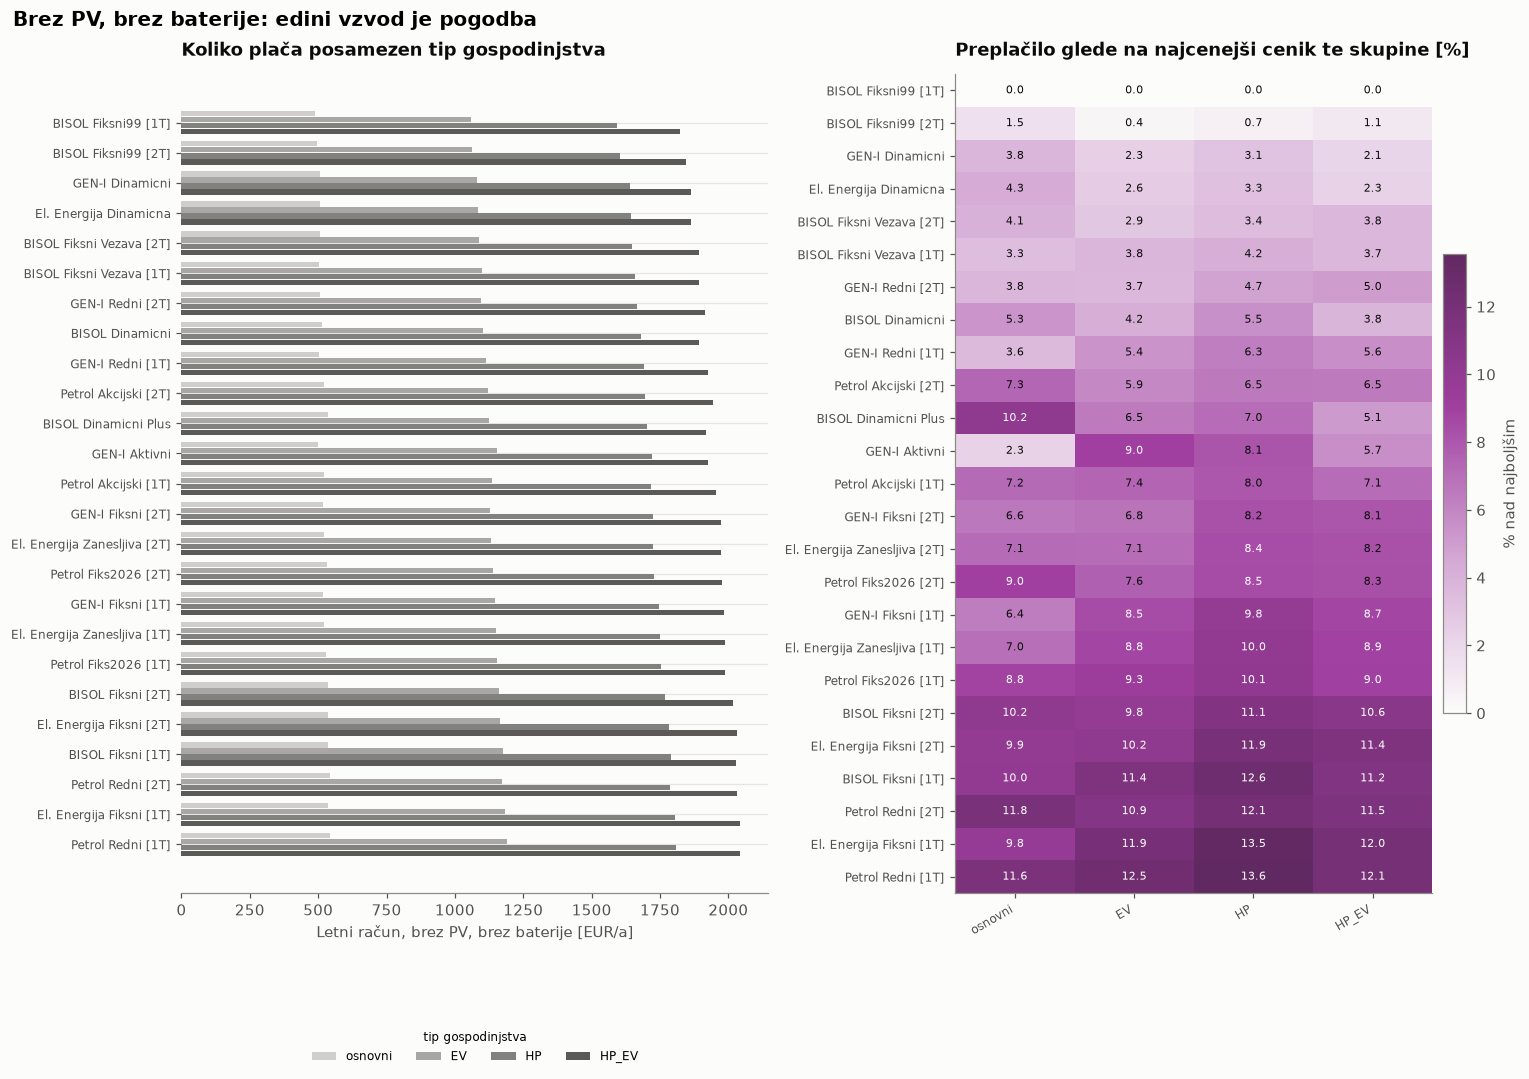

Dataset,Fluvius,Fluvius_EV,Fluvius_HP,Fluvius_HP_EV
Option,,,,
BISOL_FIKSNI99@1T,0.00,0.00,0.00,0.00
BISOL_FIKSNI99@2T,1.52,0.42,0.67,1.11
GENI_DINAMICNI,3.77,2.33,3.10,2.10
ELEN_DINAMICNA,4.34,2.59,3.28,2.25
BISOL_FIKSNI_VEZAVA@2T,4.07,2.88,3.45,3.76
BISOL_FIKSNI_VEZAVA@1T,3.35,3.79,4.19,3.73
GENI_REDNI@2T,3.78,3.67,4.74,4.99
BISOL_DINAMICNI,5.31,4.22,5.55,3.81
GENI_REDNI@1T,3.60,5.36,6.32,5.64


In [5]:
### The same ranking per household type, absolute and relative to that group's best
by_group_cost = df_no_pv.pivot_table(index="Option", columns="Dataset",
                                     values="Cost_EUR").reindex(no_pv_summary.index)
by_group_rel = 100.0 * (by_group_cost / by_group_cost.min() - 1.0)

groups = list(by_group_cost.columns)
GROUP_SHADE = group_shades(groups)

fig, axes = plt.subplots(1, 2, figsize=(14.0, max(6.4, 0.40 * len(by_group_cost))),
                         gridspec_kw={"width_ratios": [1.15, 1]})

ypos = np.arange(len(by_group_cost))[::-1]
bar_h = 0.80 / len(groups)
for i, g in enumerate(groups):
    axes[0].barh(ypos + 0.40 - bar_h * (i + 0.5), by_group_cost[g],
                 height=bar_h * 0.86, color=GROUP_SHADE[i], label=group_label(g))
axes[0].set_yticks(ypos, [short_list_name(p) for p in by_group_cost.index],
                   fontsize=8)
axes[0].set_xlabel("Letni račun, brez PV, brez baterije [EUR/a]")
axes[0].set_title("Koliko plača posamezen tip gospodinjstva", loc="left")
below_legend(axes[0], ncol=4, title="tip gospodinjstva", title_fontsize=8)
axes[0].grid(axis="x")
axes[0].spines["left"].set_visible(False)

# Relative penalty against the cheapest list for that same household type: a
# magnitude with a meaningful floor at 0 %, so one hue ramped light -> dark.
# No PV means no export, so this chapter is priced under neither regime -- it
# takes the neutral third slot rather than borrowing either regime's hue.
overpay_heatmap(axes[1], by_group_rel, "#a03fa0",
                "Preplačilo glede na najcenejši cenik te skupine [%]", fig=fig)

fig.suptitle("Brez PV, brez baterije: edini vzvod je pogodba",
             fontsize=13, fontweight="semibold", x=0.012, ha="left")
fig.tight_layout()
plt.show()

by_group_rel.round(2)

In [6]:
### Read-out: what the contract is worth next to what a battery is worth
lines = [f"{'list':24s}{'bill [EUR/a]':>14s}{'vs best [EUR/a]':>17s}{'vs best [%]':>13s}"]
for pid, row in no_pv_summary.iterrows():
    mark = "  <- cheapest" if pid == best_list else ""
    lines.append(f"{short_list_name(pid):24s}{row['Cost_EUR']:>14.2f}"
                 f"{row['Delta_EUR']:>17.2f}{row['Delta_pct']:>12.2f}%{mark}")

worst = no_pv_summary.index[-1]
switch_gain = no_pv_summary.loc[worst, "Cost_EUR"] - no_pv_summary.loc[best_list, "Cost_EUR"]
lines += [
    "",
    f"Switching from the worst option ({short_list_name(worst)}) to the best "
    f"({short_list_name(best_list)}) is worth "
    f"{switch_gain:.0f} EUR/a on average,",
    f"or {100 * switch_gain / no_pv_summary.loc[worst, 'Cost_EUR']:.1f} % of the bill -- "
    f"with no hardware, no dispatch and no battery.",
    "",
    "The three components, averaged over the households:",
    f"   energy (competitive)      {no_pv_summary['Energy_EUR'].mean():8.2f} EUR/a  "
    f"spread across lists {no_pv_summary['Energy_EUR'].max() - no_pv_summary['Energy_EUR'].min():.2f}",
    f"   fixed (agreed power etc.) {no_pv_summary['Fixed_EUR'].mean():8.2f} EUR/a  "
    f"spread across lists {no_pv_summary['Fixed_EUR'].max() - no_pv_summary['Fixed_EUR'].min():.2f}",
    f"   excess power (network)    {no_pv_summary['Excess_Power_EUR'].mean():8.2f} EUR/a  "
    f"identical on every list by construction",
    "",
    "The excess-power line is the only network item a battery can move, and it is the "
    "same number on every",
    "contract -- which is why the price list, not the network tariff, decides this "
    "question for a household with no PV.",
]

# --- 1T vs 2T, on the lists that publish both --------------------------------
pairs = sorted({hc.option_base_id(o) for o in no_pv_summary.index
                if hc.option_variant(o) != hc.VARIANT_NA})
if pairs:
    lines += ["", f"The METER, on the {len(pairs)} lists that publish both a VT/MT and an "
                  f"ET rate (2T minus 1T, so negative means 2T is cheaper):",
              f"   {'list':22s}" + "".join(f"{group_label(g):>10s}"
                                           for g in hc.NO_PV_GROUPS) + f"{'overall':>10s}"]
    by_variant = df_no_pv.pivot_table(index="Option", columns="Dataset", values="Cost_EUR")
    flips = 0
    for base in pairs:
        two, one = f"{base}@{hc.VARIANT_2T}", f"{base}@{hc.VARIANT_1T}"
        diff = by_variant.loc[two] - by_variant.loc[one]
        overall = no_pv_summary.loc[two, "Cost_EUR"] - no_pv_summary.loc[one, "Cost_EUR"]
        flips += int(diff.min() < 0 < diff.max())
        lines.append(f"   {short_list_name(base, variant=False):22s}"
                     + "".join(f"{diff[g]:>10.2f}" for g in hc.NO_PV_GROUPS)
                     + f"{overall:>10.2f}")
    lines += [
        "",
        f"The sign flips with the household type on {flips} of the {len(pairs)} lists: a "
        f"two-tariff meter only pays off for a",
        "household that moves enough demand into the MT window, and an EV or a heat pump is "
        "exactly what does that.",
        "So the meter is not a supplier-level decision -- it is a household-level one, taken "
        "on the same cenik,",
        "which is why every row above is tagged [2T] or [1T] rather than averaged into one "
        "line per list.",
        "",
        "Several lists show the SAME figure because the difference depends only on the "
        "VT-MT and VT-ET spreads,",
        "not on the price level, and most suppliers publish the same spreads "
        "(VT-MT 0.022, VT-ET 0.011). It is the",
        "level that separates those lists in the ranking above; the meter decision inside "
        "each of them is the same one.",
    ]
print("\n".join(lines))

list                      bill [EUR/a]  vs best [EUR/a]  vs best [%]
BISOL Fiksni99 [1T]            1239.88             7.36        0.64%  <- cheapest
BISOL Fiksni99 [2T]            1250.56            18.03        1.62%
GEN-I Dinamicni                1272.54            40.02        3.72%
El. Energija Dinamicna         1275.32            42.80        4.06%
BISOL Fiksni Vezava [2T]       1283.30            50.78        4.24%
BISOL Fiksni Vezava [1T]       1287.65            55.12        4.37%
GEN-I Redni [2T]               1295.79            63.26        4.83%
BISOL Dinamicni                1296.96            64.44        5.50%
GEN-I Redni [1T]               1309.33            76.80        5.66%
Petrol Akcijski [2T]           1319.87            87.35        7.32%
BISOL Dinamicni Plus           1320.82            88.30        8.40%
GEN-I Aktivni                  1324.69            92.16        6.90%
Petrol Akcijski [1T]           1332.18            99.66        8.08%
GEN-I Fiksni [2T]    

## 2. Which *samooskrba* list should a household **with PV** sign?

The same question, now for a roof. It is a different question rather than the same one
with more rows, because a PV household is choosing from a different catalogue and being
billed under a different scheme.

**Different catalogue.** All six lists here carry `zahteva_pv=True`: they are sold only
with a self-consumption device, and a household with no roof cannot sign any of them —
which is the mirror image of chapter 1, where a roof could not sign anything on offer.
The one legacy product, NET metering, is left out: it settles once a year rather than per
interval, and it is closed to new consents.

**Different scheme.** `si_samooskrba` nets **inside the 15-minute interval** and then
prices the residual. So the list decides two numbers, not one:

| | | who wins on it |
|---|---|---|
| the **import** price of the kWh the roof did not cover | as in chapter 1 | the flat and dynamic lists |
| the **buyback** credit on the surplus it could not absorb | `tip_odkupa`, and it is **not** the import price in reverse | see below |

That second line is worth being precise about, because it is where the intuition
"exporting is just importing backwards" fails. An exported kWh carries **no network
charge, no levy and no VAT** — it is a credit against the bill, not a delivered good.
On `GEN-I Samo Redni` the household imports at 0.10290 EUR/kWh of supplier price but
0.15056 delivered, and exports at 0.05390 flat. On the dynamic lists the credit is
`SIPX − pribitek` and can go **negative** when SIPX does, at exactly the hours a
south-facing roof is producing hardest.

`Delta` is measured against the cheapest list **for that same household**, then averaged,
so a list is never flattered by a household mix that suits it. `Cheapest for` counts the
households it actually wins.

In [7]:
### Every PV household on every samooskrba list it could sign, zero battery
# ~30 s: the per-interval import rate and export credit depend only on the
# calendar and the market price, never on the household, so one pass per list
# prices all 20.
PV_CACHE = cache_path("pv_tariff_comparison_buyback", PER_GROUP)
RUN_PV = False        # True -> recompute instead of reading the cache

# Keyed on the agreed-power rule as well: these bills are mostly network
# charges, and a cache written against a different dogovorjena moc is a
# different bill, not an older one.
cached = pd.read_csv(PV_CACHE) if PV_CACHE.exists() else None
if cached is not None and hc.agreed_power_tag(cached) != {hc.AGREED_POWER_TAG}:
    print(f"cache written under agreed power {sorted(hc.agreed_power_tag(cached))} != "
          f"{hc.AGREED_POWER_TAG!r}; recomputing")
    cached = None
if cached is not None and hc.sample_tag(cached) != {PER_GROUP}:
    print(f"cache written for per_group {sorted(hc.sample_tag(cached), key=str)} != "
          f"{PER_GROUP}; recomputing")
    cached = None

if RUN_PV or cached is None:
    df_pv = hc.pv_tariff_comparison(per_group=PER_GROUP, buyback=True, verbose=True)
    df_pv.to_csv(PV_CACHE, index=False)
else:
    df_pv = cached

pv_summary = hc.summarize_pv_tariffs(df_pv)
pv_best = pv_summary.index[0]
pv_units = df_pv.groupby(["Dataset", "Household"]).ngroups

print(f"{pv_units} households ({', '.join(hc.PV_GROUPS)}), {len(pv_summary)} samooskrba "
      f"options from {df_pv['Paket_ID'].nunique()} lists, no battery, full year under "
      f"{hc.PROSUMER_SCHEME}")
print(f"meter registers      : {df_pv['Import_kWh'].mean():.0f} kWh/a offtake, "
      f"{df_pv['Export_kWh'].mean():.0f} kWh/a injection on average "
      f"(export/import ratio {df_pv['Export_kWh'].mean() / df_pv['Import_kWh'].mean():.2f})\n")
print(f"cheapest on average  : {pv_best}  "
      f"({pv_summary.loc[pv_best, 'Cost_EUR']:.0f} EUR/a, cheapest for "
      f"{pv_summary.loc[pv_best, 'Cheapest_For']} of {pv_units} households)")
print(f"most expensive       : {pv_summary.index[-1]}  "
      f"({pv_summary['Cost_EUR'].iloc[-1]:.0f} EUR/a, "
      f"{pv_summary['Delta_pct'].iloc[-1]:.1f} % above the best available)")
print(f"spread, best to worst: "
      f"{pv_summary['Cost_EUR'].iloc[-1] - pv_summary['Cost_EUR'].iloc[0]:.0f} EUR/a")
print(f"buyback credit       : {pv_summary['Export_Credit_EUR'].min():.0f} to "
      f"{pv_summary['Export_Credit_EUR'].max():.0f} EUR/a depending on the list, "
      f"on identical exported energy")

pv_summary.rename(columns={
    "Cost_EUR": "Bill [EUR/a]",
    "Delta_EUR": "vs best [EUR/a]",
    "Delta_pct": "vs best [%]",
    "Worst_Delta_pct": "worst household [%]",
    "Energy_EUR": "energy net [EUR/a]",
    "Import_EUR": "import [EUR/a]",
    "Export_Credit_EUR": "buyback credit [EUR/a]",
    "Fixed_EUR": "fixed [EUR/a]",
    "Excess_Power_EUR": "excess power [EUR/a]",
    "Export_kWh": "exported [kWh/a]",
    "Cheapest_For": "cheapest for",
}).round(2)

20 households (Fluvius_PV, Fluvius_PV_EV, Fluvius_PV_HP, Fluvius_PV_HP_EV), 7 samooskrba options from 6 lists, no battery, full year under si_samooskrba
meter registers      : 4141 kWh/a offtake, 2215 kWh/a injection on average (export/import ratio 0.53)

cheapest on average  : GENI_SAMO_REDNI  (768 EUR/a, cheapest for 16 of 20 households)
most expensive       : PETROL_SAMOOSKRBA@1T  (978 EUR/a, 39.9 % above the best available)
spread, best to worst: 210 EUR/a
buyback credit       : 0 to 138 EUR/a depending on the list, on identical exported energy


,Supplier,Structure,Variant,Buyback,Households,Bill [EUR/a],vs best [EUR/a],vs best [%],worst household [%],energy net [EUR/a],fixed [EUR/a],excess power [EUR/a],import [EUR/a],buyback credit [EUR/a],exported [kWh/a],cheapest for
Option,,,,,,,,,,,,,,,,
GENI_SAMO_REDNI,GEN-I,1T: ET 0.10290,-,0.05390 flat,20,768.42,3.81,0.31,3.92,507.35,251.85,9.22,626.71,119.36,2214.52,16
GENI_SAMO_DINAMICNI,GEN-I,dynamic: SIPX + 0.01199,-,SIPX - 0.01199,20,788.37,23.76,4.47,15.52,512.95,266.20,9.22,650.57,137.62,2214.52,3
BISOL_SAMO_DINAMICNA,BISOL Energija,dynamic: SIPX + 0.01300,-,SIPX - 0.01300,20,790.73,26.12,4.60,15.33,520.29,261.22,9.22,655.67,135.38,2214.52,1
GENI_SAMO_AKTIVNI,GEN-I,4 blocks: 0.04090 -> 0.19290,-,"4 blocks, 0.00190 -> 0.14990",20,906.87,142.26,21.93,50.48,645.80,251.85,9.22,747.74,101.95,2214.52,0
GENI_SAMO_FIKSNI,GEN-I,4 blocks: 0.04590 -> 0.19790,-,"4 blocks, 0.00190 -> 0.14490",20,937.12,172.51,26.45,57.81,676.05,251.85,9.22,773.01,96.96,2214.52,0
PETROL_SAMOOSKRBA@2T,Petrol,2T: VT 0.12795 / MT 0.10795,2T,no buyback,20,969.14,204.53,38.82,143.98,693.57,266.34,9.22,693.57,0.00,2214.52,0
PETROL_SAMOOSKRBA@1T,Petrol,1T: ET 0.11795,1T,no buyback,20,978.32,213.71,39.95,145.79,702.75,266.34,9.22,702.75,0.00,2214.52,0


findfont: Failed to find font weight semibold, now using 700.


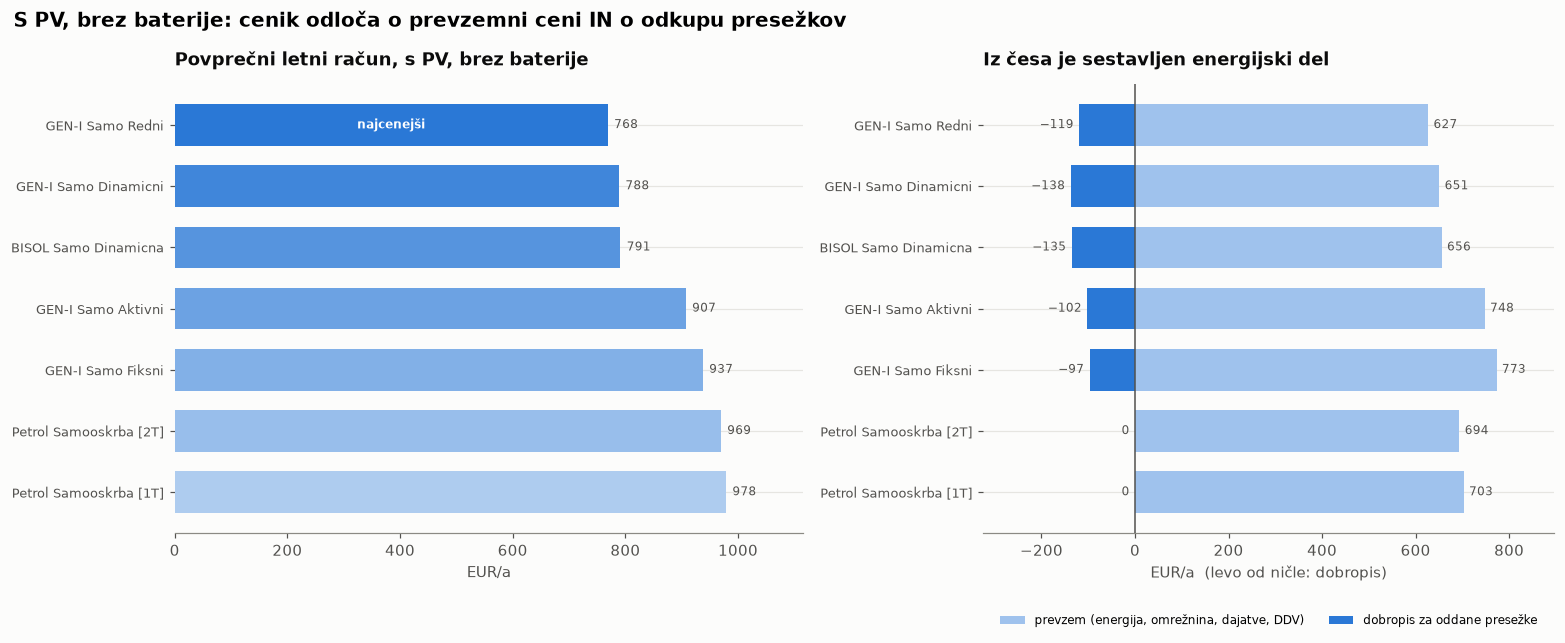

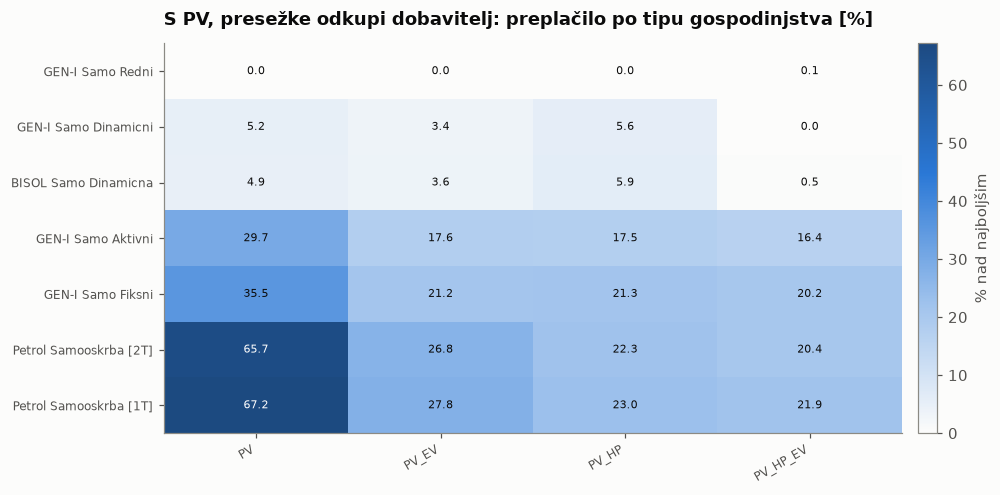

Dataset,Fluvius_PV,Fluvius_PV_EV,Fluvius_PV_HP,Fluvius_PV_HP_EV
Option,,,,
GENI_SAMO_REDNI,0.00,0.00,0.00,0.15
GENI_SAMO_DINAMICNI,5.15,3.37,5.62,0.00
BISOL_SAMO_DINAMICNA,4.91,3.61,5.86,0.49
GENI_SAMO_AKTIVNI,29.72,17.62,17.54,16.39
GENI_SAMO_FIKSNI,35.53,21.25,21.29,20.24
PETROL_SAMOOSKRBA@2T,65.72,26.82,22.29,20.37
PETROL_SAMOOSKRBA@1T,67.18,27.78,23.02,21.92


In [8]:
### The ranking, and where each list's bill comes from
by_group_pv = df_pv.pivot_table(index="Option", columns="Dataset",
                                values="Cost_EUR").reindex(pv_summary.index)
by_group_pv_rel = 100.0 * (by_group_pv / by_group_pv.min() - 1.0)

fig, axes = plt.subplots(1, 2, figsize=(14.4, 6.0),
                         gridspec_kw={"width_ratios": [1.1, 1]})

ranked_bill_panel(axes[0], pv_summary, REGIME_COLOR["credited"],
                  "Povprečni letni račun, s PV, brez baterije",
                  "EUR/a")

# The composition, on the same row order: what the household pays for import,
# and how much of it the buyback gives back. Two stacked parts of ONE bar with
# a 2 px surface gap between them -- not a second axis, and not a second chart,
# because the credit is only meaningful next to the import it offsets.
ypos = np.arange(len(pv_summary))[::-1]
imp = pv_summary["Import_EUR"].to_numpy()
cred = pv_summary["Export_Credit_EUR"].to_numpy()
axes[1].barh(ypos, imp, height=0.68, color=_mix(REGIME_COLOR["credited"], "#ffffff", 0.55),
             label="prevzem (energija, omrežnina, dajatve, DDV)")
axes[1].barh(ypos, -cred, height=0.68, color=REGIME_COLOR["credited"],
             label="dobropis za oddane presežke")
axes[1].axvline(0, color=INK_2, lw=1.0, zorder=4)
axes[1].set_yticks(ypos, [short_list_name(p) for p in pv_summary.index], fontsize=8.5)
for y, i, c in zip(ypos, imp, cred):
    axes[1].text(i + imp.max() * 0.015, y, f"{i:.0f}", va="center", ha="left",
                 fontsize=8, color=INK_2)
    axes[1].text(-c - imp.max() * 0.015, y, "0" if c < 0.5 else f"−{c:.0f}",
                 va="center", ha="right", fontsize=8, color=INK_2)
axes[1].set_xlim(-imp.max() * 0.42, imp.max() * 1.16)
axes[1].set_xlabel("EUR/a  (levo od ničle: dobropis)")
axes[1].set_title("Iz česa je sestavljen energijski del", loc="left")
below_legend(axes[1], ncol=2)
axes[1].grid(axis="x")
axes[1].spines["left"].set_visible(False)

fig.suptitle("S PV, brez baterije: cenik odloča o prevzemni ceni IN o odkupu presežkov",
             fontsize=13, fontweight="semibold", x=0.012, ha="left")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9.2, 4.6))
overpay_heatmap(ax, by_group_pv_rel, REGIME_COLOR["credited"],
                "Preplačilo glede na najcenejši cenik te skupine [%]", fig=fig)
ax.set_title("S PV, presežke odkupi dobavitelj: preplačilo po tipu gospodinjstva [%]",
             loc="left")
fig.tight_layout()
plt.show()

by_group_pv_rel.round(2)

In [9]:
### Read-out: the import price, the buyback, and which of the two decides it
lines = [f"{'list':26s}{'bill':>10s}{'import':>10s}{'credit':>9s}"
         f"{'fixed':>9s}{'vs best':>10s}"]
for pid, row in pv_summary.iterrows():
    mark = "  <- cheapest" if pid == pv_best else ""
    lines.append(f"{short_list_name(pid):26s}{row['Cost_EUR']:>10.2f}"
                 f"{row['Import_EUR']:>10.2f}{-row['Export_Credit_EUR']:>9.2f}"
                 f"{row['Fixed_EUR']:>9.2f}{row['Delta_pct']:>9.2f}%{mark}")

pv_worst = pv_summary.index[-1]
pv_switch = pv_summary.loc[pv_worst, "Cost_EUR"] - pv_summary.loc[pv_best, "Cost_EUR"]
imp_spread = pv_summary["Import_EUR"].max() - pv_summary["Import_EUR"].min()
# Two different levers, and they must not be pooled. Petrol credits nothing, so
# the full spread of the credit column measures "a buyback or none"; the spread
# among the lists that DO buy back measures "which buyback rate", which is the
# choice a household actually faces once it has ruled Petrol out.
credited_only = pv_summary[pv_summary["Export_Credit_EUR"] > 0]["Export_Credit_EUR"]
has_buyback = float(credited_only.mean())
rate_spread = float(credited_only.max() - credited_only.min())

lines += [
    "",
    f"Switching from the worst list ({short_list_name(pv_worst)}) to the best "
    f"({short_list_name(pv_best)}) is worth {pv_switch:.0f} EUR/a on average,",
    f"or {100 * pv_switch / pv_summary.loc[pv_worst, 'Cost_EUR']:.1f} % of the bill -- "
    f"with no hardware and no dispatch, on a roof the household already owns.",
    "",
    "Three levers, on identical energy, and they are not the same size:",
    f"   having ANY buyback  {has_buyback:7.2f} EUR/a  "
    f"(mean credit on the {len(credited_only)} lists that buy back, against 0 on Petrol)",
    f"   WHICH buyback rate  {rate_spread:7.2f} EUR/a  "
    f"(best to worst among those {len(credited_only)})",
    f"   which IMPORT price  {imp_spread:7.2f} EUR/a  "
    f"(best to worst across all {len(pv_summary)})",
    "",
    "So the import price and the presence of a buyback are levers of the same order, and "
    "the buyback",
    f"RATE is {imp_spread / rate_spread:.1f}x smaller than either -- which is why "
    f"{short_list_name(pv_best)} wins here on a 0.05390 flat",
    "buyback, the LOWEST rate of the five that buy back, while charging the cheapest "
    "import price.",
    "",
    f"The excess-power charge is {pv_summary['Excess_Power_EUR'].mean():.2f} EUR/a and "
    f"identical on all {len(pv_summary)} lists,",
    "because it is a network charge -- no contract can move it, and it is the one line a "
    "battery could.",
]
print("\n".join(lines))

list                            bill    import   credit    fixed   vs best
GEN-I Samo Redni              768.42    626.71  -119.36   251.85     0.31%  <- cheapest
GEN-I Samo Dinamicni          788.37    650.57  -137.62   266.20     4.47%
BISOL Samo Dinamicna          790.73    655.67  -135.38   261.22     4.60%
GEN-I Samo Aktivni            906.87    747.74  -101.95   251.85    21.93%
GEN-I Samo Fiksni             937.12    773.01   -96.96   251.85    26.45%
Petrol Samooskrba [2T]        969.14    693.57    -0.00   266.34    38.82%
Petrol Samooskrba [1T]        978.32    702.75    -0.00   266.34    39.95%

Switching from the worst list (Petrol Samooskrba [1T]) to the best (GEN-I Samo Redni) is worth 210 EUR/a on average,
or 21.5 % of the bill -- with no hardware and no dispatch, on a roof the household already owns.

Three levers, on identical energy, and they are not the same size:
   having ANY buyback   118.26 EUR/a  (mean credit on the 5 lists that buy back, against 0 on Petrol)
  

## 3. The same households and the same lists, with **no right to sell the surplus**

Chapter 2 priced every exported kWh at the list's own `tip_odkupa`. This chapter prices
it at **zero** and changes nothing else — same households, same lists, same import
prices, same fixed charges, same excess-power charge, same interval-level netting. The
only term that moves is the credit on the surplus.

**Who this is.** A household in the new self-consumption scheme whose supplier does not
buy surpluses. It is not hypothetical: `PETROL_SAMOOSKRBA` is exactly that contract in
the catalogue (*Samooskrba — brez odkupa presežkov*, `tip_odkupa=NI`), and
`si_obracun._cena_oddaje` returns 0.00000 for it. Which gives the chapter a built-in
check: **that one list must come out bit-identical to its chapter-2 row**, since zeroing
a credit that was already zero can do nothing. The cell below asserts it.

**What the surplus is worth when nobody buys it.** Nothing, on this bill — but note what
that does *not* mean. Interval-level netting is **physical**: within the 15 minutes it is
generated, a PV kWh still displaces an imported one whatever the contract says, and that
displacement is already baked into these profiles (the registers net before the data
starts). So a household with no buyback has not lost its roof; it has lost the residue
the roof could not absorb in the quarter-hour it appeared. On this sample that residue is
large — the mean household injects nearly as much as it takes — but it is worth much less
per kWh than the import it cannot displace.

**What to expect from the ranking.** Once every list credits exports at zero, the six
lists differ only in import price and monthly fee. So the ranking should both **compress**
and **re-order**: compress because the buyback spread is gone, and re-order because the
list with the best buyback is not necessarily the one with the cheapest import.

In [10]:
### The same 20 PV households, exported kWh priced at zero
PV_NOSALE_CACHE = cache_path("pv_tariff_comparison_nosale", PER_GROUP)
RUN_PV_NOSALE = False        # True -> recompute instead of reading the cache

cached = pd.read_csv(PV_NOSALE_CACHE) if PV_NOSALE_CACHE.exists() else None
if cached is not None and hc.agreed_power_tag(cached) != {hc.AGREED_POWER_TAG}:
    print(f"cache written under agreed power {sorted(hc.agreed_power_tag(cached))} != "
          f"{hc.AGREED_POWER_TAG!r}; recomputing")
    cached = None
if cached is not None and hc.sample_tag(cached) != {PER_GROUP}:
    print(f"cache written for per_group {sorted(hc.sample_tag(cached), key=str)} != "
          f"{PER_GROUP}; recomputing")
    cached = None

if RUN_PV_NOSALE or cached is None:
    df_pv0 = hc.pv_tariff_comparison(per_group=PER_GROUP, buyback=False, verbose=True)
    df_pv0.to_csv(PV_NOSALE_CACHE, index=False)
else:
    df_pv0 = cached

pv0_summary = hc.summarize_pv_tariffs(df_pv0)
pv0_best = pv0_summary.index[0]

# --- the two checks that say the flag did only what it claims -----------------
# 1. Every exported kWh is credited at zero, on every list and every household.
assert float(df_pv0["Export_Credit_EUR"].abs().max()) == 0.0

# 2. PETROL_SAMOOSKRBA already had tip_odkupa=NI, so its bill cannot have moved.
#    Any drift here would mean the flag is reaching something other than the
#    buyback -- the import side, the fixed charge or the peak.
key = ["Dataset", "Household", "Option"]
petrol = "PETROL_SAMOOSKRBA"
a = df_pv[df_pv["Paket_ID"] == petrol].set_index(key)["Cost_EUR"].sort_index()
b = df_pv0[df_pv0["Paket_ID"] == petrol].set_index(key)["Cost_EUR"].sort_index()
drift = float((a - b).abs().max())
assert drift < 1e-9, f"{petrol} moved by {drift:.2e} EUR when only the buyback changed"

# 3. And the only thing that moved anywhere else is the credit itself.
joined = df_pv.set_index(key).join(df_pv0.set_index(key), rsuffix="_0")
residual = float((joined["Cost_EUR_0"]
                  - (joined["Cost_EUR"] + joined["Export_Credit_EUR"])).abs().max())
assert residual < 1e-9, f"import/fixed/peak moved too, by up to {residual:.2e} EUR"

print(f"checks passed: {petrol} identical to {drift:.1e} EUR on both of its metering "
      f"variants\n(it already had no buyback), and every other option moved by exactly "
      f"its lost credit ({residual:.1e} EUR residual)\n")

print(f"cheapest on average  : {pv0_best}  "
      f"({pv0_summary.loc[pv0_best, 'Cost_EUR']:.0f} EUR/a, cheapest for "
      f"{pv0_summary.loc[pv0_best, 'Cheapest_For']} of {pv_units} households)")
print(f"most expensive       : {pv0_summary.index[-1]}  "
      f"({pv0_summary['Cost_EUR'].iloc[-1]:.0f} EUR/a, "
      f"{pv0_summary['Delta_pct'].iloc[-1]:.1f} % above the best available)")
print(f"spread, best to worst: "
      f"{pv0_summary['Cost_EUR'].iloc[-1] - pv0_summary['Cost_EUR'].iloc[0]:.0f} EUR/a"
      f"  (was {pv_summary['Cost_EUR'].iloc[-1] - pv_summary['Cost_EUR'].iloc[0]:.0f} "
      f"EUR/a with the buyback -- the spread compresses, as it must)")
rank_before = list(pv_summary.index)
rank_after = list(pv0_summary.index)
moved = [p for p in rank_after if rank_before.index(p) != rank_after.index(p)]
print(f"ranking              : {'unchanged' if not moved else 're-ordered'}"
      + (f" -- {', '.join(short_list_name(p) for p in moved)} change place"
         if moved else ""))

pv0_summary.rename(columns={
    "Cost_EUR": "Bill [EUR/a]",
    "Delta_EUR": "vs best [EUR/a]",
    "Delta_pct": "vs best [%]",
    "Worst_Delta_pct": "worst household [%]",
    "Energy_EUR": "energy net [EUR/a]",
    "Import_EUR": "import [EUR/a]",
    "Export_Credit_EUR": "buyback credit [EUR/a]",
    "Fixed_EUR": "fixed [EUR/a]",
    "Excess_Power_EUR": "excess power [EUR/a]",
    "Export_kWh": "exported [kWh/a]",
    "Cheapest_For": "cheapest for",
}).round(2)

checks passed: PETROL_SAMOOSKRBA identical to 0.0e+00 EUR on both of its metering variants
(it already had no buyback), and every other option moved by exactly its lost credit (4.5e-13 EUR residual)

cheapest on average  : GENI_SAMO_REDNI  (888 EUR/a, cheapest for 18 of 20 households)
most expensive       : GENI_SAMO_FIKSNI  (1034 EUR/a, 16.3 % above the best available)
spread, best to worst: 146 EUR/a  (was 210 EUR/a with the buyback -- the spread compresses, as it must)
ranking              : re-ordered -- Petrol Samooskrba [2T], Petrol Samooskrba [1T], GEN-I Samo Aktivni, GEN-I Samo Fiksni change place


,Supplier,Structure,Variant,Buyback,Households,Bill [EUR/a],vs best [EUR/a],vs best [%],worst household [%],energy net [EUR/a],fixed [EUR/a],excess power [EUR/a],import [EUR/a],buyback credit [EUR/a],exported [kWh/a],cheapest for
Option,,,,,,,,,,,,,,,,
GENI_SAMO_REDNI,GEN-I,1T: ET 0.10290,-,zeroed,20,887.78,0.79,0.05,0.84,626.71,251.85,9.22,626.71,0.0,2214.52,18
GENI_SAMO_DINAMICNI,GEN-I,dynamic: SIPX + 0.01199,-,zeroed,20,925.99,39.00,5.77,11.24,650.57,266.20,9.22,650.57,0.0,2214.52,2
BISOL_SAMO_DINAMICNA,BISOL Energija,dynamic: SIPX + 0.01300,-,zeroed,20,926.11,39.12,5.57,10.18,655.67,261.22,9.22,655.67,0.0,2214.52,0
PETROL_SAMOOSKRBA@2T,Petrol,2T: VT 0.12795 / MT 0.10795,2T,zeroed,20,969.14,82.14,9.65,11.97,693.57,266.34,9.22,693.57,0.0,2214.52,0
PETROL_SAMOOSKRBA@1T,Petrol,1T: ET 0.11795,1T,zeroed,20,978.32,91.33,10.53,12.81,702.75,266.34,9.22,702.75,0.0,2214.52,0
GENI_SAMO_AKTIVNI,GEN-I,4 blocks: 0.04090 -> 0.19290,-,zeroed,20,1008.82,121.82,13.57,18.22,747.74,251.85,9.22,747.74,0.0,2214.52,0
GENI_SAMO_FIKSNI,GEN-I,4 blocks: 0.04590 -> 0.19790,-,zeroed,20,1034.08,147.09,16.32,21.42,773.01,251.85,9.22,773.01,0.0,2214.52,0


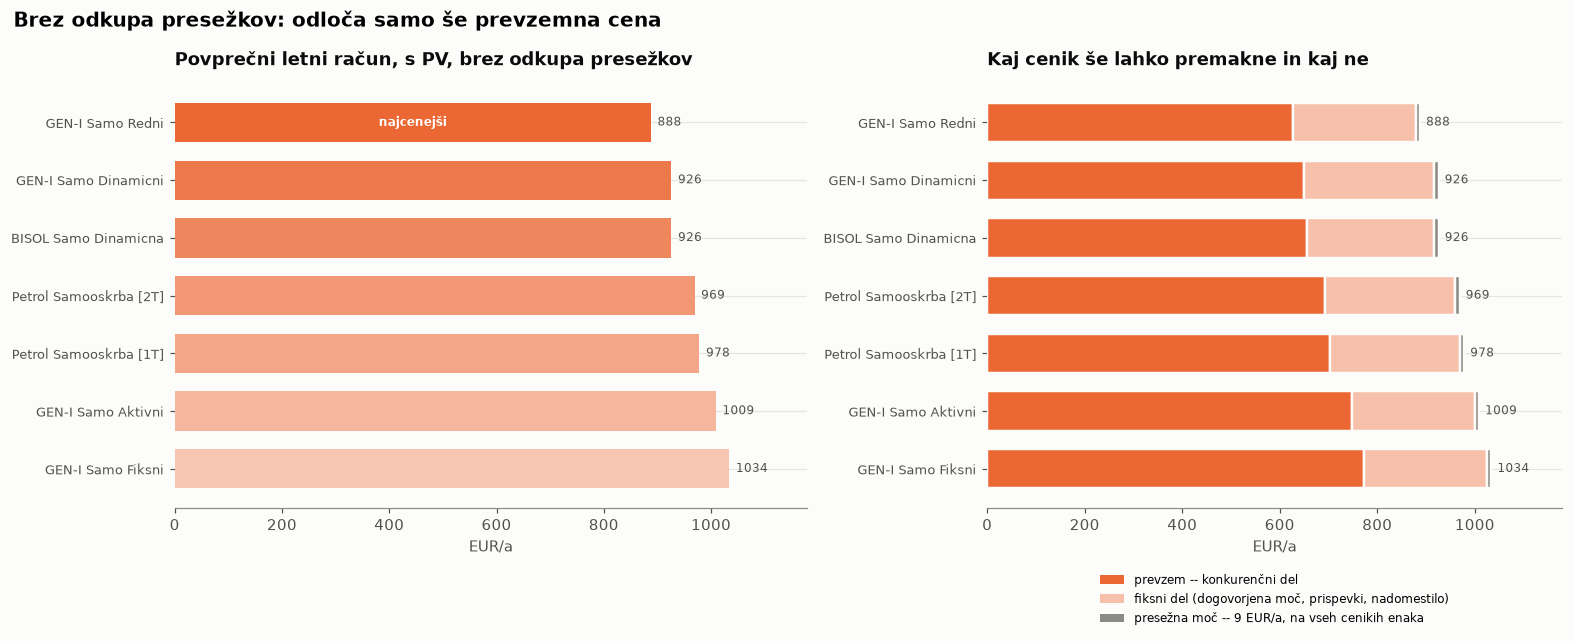

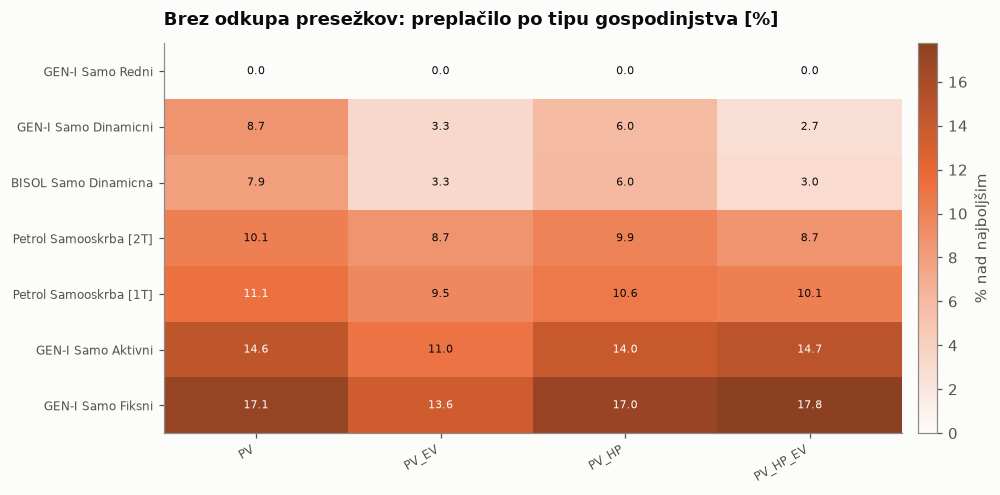

Dataset,Fluvius_PV,Fluvius_PV_EV,Fluvius_PV_HP,Fluvius_PV_HP_EV
Option,,,,
GENI_SAMO_REDNI,0.00,0.00,0.00,0.00
GENI_SAMO_DINAMICNI,8.65,3.32,6.01,2.69
BISOL_SAMO_DINAMICNA,7.86,3.26,6.03,2.96
PETROL_SAMOOSKRBA@2T,10.14,8.70,9.91,8.73
PETROL_SAMOOSKRBA@1T,11.10,9.53,10.56,10.13
GENI_SAMO_AKTIVNI,14.61,10.97,14.02,14.72
GENI_SAMO_FIKSNI,17.06,13.57,16.97,17.75


In [11]:
### The ranking with no buyback, and how much of the bill is now beyond reach
by_group_pv0 = df_pv0.pivot_table(index="Option", columns="Dataset",
                                  values="Cost_EUR").reindex(pv0_summary.index)
by_group_pv0_rel = 100.0 * (by_group_pv0 / by_group_pv0.min() - 1.0)

fig, axes = plt.subplots(1, 2, figsize=(14.4, 6.0),
                         gridspec_kw={"width_ratios": [1.1, 1]})

ranked_bill_panel(axes[0], pv0_summary, REGIME_COLOR["nosale"],
                  "Povprečni letni račun, s PV, brez odkupa presežkov",
                  "EUR/a")

# What is left to choose between. With the credit gone the bill is import +
# fixed + excess, and only the first two differ between lists at all -- so the
# panel splits the bar into the part a contract moves and the part it cannot.
ypos = np.arange(len(pv0_summary))[::-1]
imp0 = pv0_summary["Import_EUR"].to_numpy()
fix0 = pv0_summary["Fixed_EUR"].to_numpy()
exc0 = pv0_summary["Excess_Power_EUR"].to_numpy()
# edgecolor=SURFACE gives the 2 px gap that keeps two stacked fills from
# reading as one long bar.
seg = dict(height=0.68, edgecolor=SURFACE, linewidth=1.6)
axes[1].barh(ypos, imp0, color=REGIME_COLOR["nosale"], **seg,
             label="prevzem -- konkurenčni del")
axes[1].barh(ypos, fix0, left=imp0,
             color=_mix(REGIME_COLOR["nosale"], "#ffffff", 0.58), **seg,
             label="fiksni del (dogovorjena moč, prispevki, nadomestilo)")
axes[1].barh(ypos, exc0, left=imp0 + fix0, color=MUTED, **seg,
             label="presežna moč -- na vseh cenikih enaka")
axes[1].set_yticks(ypos, [short_list_name(p) for p in pv0_summary.index], fontsize=8.5)
bar_labels(axes[1], ypos, (imp0 + fix0 + exc0))
axes[1].set_xlim(0, (imp0 + fix0 + exc0).max() * 1.14)
axes[1].set_xlabel("EUR/a")
axes[1].set_title("Kaj cenik še lahko premakne in kaj ne", loc="left")
# Explicit handles: the bars carry a SURFACE edge to hold the 2 px gap between
# segments, which at legend size would read as a hollow swatch.
below_legend(
    axes[1],
    [Patch(facecolor=REGIME_COLOR["nosale"], edgecolor="none"),
     Patch(facecolor=_mix(REGIME_COLOR["nosale"], "#ffffff", 0.58), edgecolor="none"),
     Patch(facecolor=MUTED, edgecolor="none")],
    ["prevzem -- konkurenčni del",
     "fiksni del (dogovorjena moč, prispevki, nadomestilo)",
     f"presežna moč -- {exc0.mean():.0f} EUR/a, na vseh cenikih enaka"],
    ncol=1, y=-0.13)
axes[1].grid(axis="x")
axes[1].spines["left"].set_visible(False)

fig.suptitle("Brez odkupa presežkov: odloča samo še prevzemna cena",
             fontsize=13, fontweight="semibold", x=0.012, ha="left")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9.2, 4.6))
overpay_heatmap(ax, by_group_pv0_rel, REGIME_COLOR["nosale"],
                "Brez odkupa presežkov: preplačilo po tipu gospodinjstva [%]", fig=fig)
fig.tight_layout()
plt.show()

by_group_pv0_rel.round(2)

In [12]:
### Read-out: what is left to choose between when the surplus is worth nothing
lines = [f"{'list':26s}{'bill':>10s}{'import':>10s}{'fixed':>9s}{'vs best':>10s}"]
for pid, row in pv0_summary.iterrows():
    mark = "  <- cheapest" if pid == pv0_best else ""
    lines.append(f"{short_list_name(pid):26s}{row['Cost_EUR']:>10.2f}"
                 f"{row['Import_EUR']:>10.2f}{row['Fixed_EUR']:>9.2f}"
                 f"{row['Delta_pct']:>9.2f}%{mark}")

pv0_worst = pv0_summary.index[-1]
pv0_switch = pv0_summary.loc[pv0_worst, "Cost_EUR"] - pv0_summary.loc[pv0_best, "Cost_EUR"]
lines += [
    "",
    f"Best to worst is now {pv0_switch:.0f} EUR/a "
    f"({100 * pv0_switch / pv0_summary.loc[pv0_worst, 'Cost_EUR']:.1f} % of the bill), "
    f"against {pv_switch:.0f} EUR/a in chapter 2.",
    f"The buyback was carrying "
    f"{100 * (pv_switch - pv0_switch) / pv_switch:.0f} % of the spread between the best "
    f"and the worst contract.",
    "",
    "The bill, averaged over the households and the lists:",
    f"   import (competitive)      {pv0_summary['Import_EUR'].mean():8.2f} EUR/a  "
    f"spread across lists {pv0_summary['Import_EUR'].max() - pv0_summary['Import_EUR'].min():.2f}",
    f"   fixed (agreed power etc.) {pv0_summary['Fixed_EUR'].mean():8.2f} EUR/a  "
    f"spread across lists {pv0_summary['Fixed_EUR'].max() - pv0_summary['Fixed_EUR'].min():.2f}",
    f"   excess power (network)    {pv0_summary['Excess_Power_EUR'].mean():8.2f} EUR/a  "
    f"identical on every list by construction",
    "",
    f"And the surplus that is now worth nothing: "
    f"{df_pv0['Export_kWh'].mean():.0f} kWh/a per household, which the best chapter-2 "
    f"list would have paid",
    f"{pv_summary.loc[pv_best, 'Export_Credit_EUR']:.0f} EUR/a for "
    f"({100 * pv_summary.loc[pv_best, 'Export_Credit_EUR'] / pv_summary.loc[pv_best, 'Cost_EUR']:.0f} "
    f"% of that bill).",
]
print("\n".join(lines))

list                            bill    import    fixed   vs best
GEN-I Samo Redni              887.78    626.71   251.85     0.05%  <- cheapest
GEN-I Samo Dinamicni          925.99    650.57   266.20     5.77%
BISOL Samo Dinamicna          926.11    655.67   261.22     5.57%
Petrol Samooskrba [2T]        969.14    693.57   266.34     9.65%
Petrol Samooskrba [1T]        978.32    702.75   266.34    10.53%
GEN-I Samo Aktivni           1008.82    747.74   251.85    13.57%
GEN-I Samo Fiksni            1034.08    773.01   251.85    16.32%

Best to worst is now 146 EUR/a (14.1 % of the bill), against 210 EUR/a in chapter 2.
The buyback was carrying 30 % of the spread between the best and the worst contract.

The bill, averaged over the households and the lists:
   import (competitive)        692.86 EUR/a  spread across lists 146.30
   fixed (agreed power etc.)   259.38 EUR/a  spread across lists 14.49
   excess power (network)        9.22 EUR/a  identical on every list by construction

And 

## 4. What the right to sell the surplus is worth — best 3 and worst 3 contracts

Chapters 2 and 3 are two contracts for the same house. This chapter puts them on the same
row: the **best 3 and the worst 3** samooskrba options for a PV household, each shown once
with its buyback and once with the surplus priced at zero. The middle of the ranking is
dropped rather than plotted — it carries no finding the ends do not, and six rows is what
fits before a dumbbell chart stops being readable.

Ranking is by the **credited** bill, because that is the contract a household with a roof
would actually be offered; each row then carries its rank in the zero-export ranking too, so
a re-order between the two regimes is visible rather than hidden by the choice of sort.

Three things this comparison can settle that neither chapter can alone:

1. **The euro value of the buyback**, per contract — the horizontal distance between the two
   dots on each row. It is not the same on every one, because they do not pay the same rate
   for the same exported kWh, and one of them pays nothing at all.
2. **Whether the right to sell changes which contract to sign.** If the ranking survives
   zeroing the credit, a household can choose its contract without knowing whether it will be
   allowed to sell. If it does not, the two decisions are entangled.
3. **What the metering variant is worth next to it.** `Petrol Samooskrba` appears as both
   `[2T]` and `[1T]`, the only samooskrba list that publishes both — so the gap between those
   two rows is the price of the *meter*, measurable against the price of the *buyback* on
   every other row.

**One caution about reading euros here.** The zero-export bill is always the higher of the two,
so the gap is always "what the buyback is worth" — never "what the household saves". Both are
contracts available to the same household, so the right way to read the gap is as the maximum a
household should pay per year for a supplier that buys its surplus.

In [13]:
### Best 3 and worst 3 contracts, each under both regimes
TOP_N = 3
ranked = list(pv_summary.index)                 # by credited bill, cheapest first
best = ranked[:TOP_N]
worst = ranked[-TOP_N:]
# Guard the small-catalogue case: with <= 2*TOP_N options the two ends would
# overlap and a contract would be drawn twice.
worst = [o for o in worst if o not in best]
shortlist = best + worst
middle = [o for o in ranked if o not in shortlist]

rank0 = {o: i for i, o in enumerate(pv0_summary.index)}
head = pd.DataFrame({
    "Credited_EUR": pv_summary.loc[shortlist, "Cost_EUR"],
    "NoSale_EUR": pv0_summary.loc[shortlist, "Cost_EUR"],
    "Variant": [hc.option_variant(o) for o in shortlist],
    "Structure": [hc.tariff_structure_label(o) for o in shortlist],
    "Buyback": [hc.buyback_rate_label(o) for o in shortlist],
    "End": ["best" if o in best else "worst" for o in shortlist],
    "Rank_Credited": [ranked.index(o) + 1 for o in shortlist],
    "Rank_NoSale": [rank0[o] + 1 for o in shortlist],
})
head["Worth_EUR"] = head["NoSale_EUR"] - head["Credited_EUR"]
head["Worth_pct"] = 100.0 * head["Worth_EUR"] / head["NoSale_EUR"]

print(f"{len(pv_summary)} samooskrba options ranked by the credited bill; showing the "
      f"best {len(best)} and worst {len(worst)}")
print(f"   best  : {', '.join(short_list_name(o) for o in best)}")
print(f"   worst : {', '.join(short_list_name(o) for o in worst)}")
if middle:
    print(f"   not shown ({len(middle)}): "
          f"{', '.join(short_list_name(o) for o in middle)}")
reordered = head[head["Rank_Credited"] != head["Rank_NoSale"]]
print(f"\nranking under the two regimes: "
      f"{'identical' if reordered.empty else 'differs on ' + ', '.join(short_list_name(o) for o in reordered.index)}")

head.rename(index=short_list_name).rename(columns={
    "Credited_EUR": "with buyback [EUR/a]",
    "NoSale_EUR": "no sale [EUR/a]",
    "Variant": "meter",
    "Structure": "billed on",
    "Buyback": "buyback terms",
    "End": "end of ranking",
    "Rank_Credited": "rank, credited",
    "Rank_NoSale": "rank, no sale",
    "Worth_EUR": "right to sell worth [EUR/a]",
    "Worth_pct": "worth [% of bill]",
}).round(2)

7 samooskrba options ranked by the credited bill; showing the best 3 and worst 3
   best  : GEN-I Samo Redni, GEN-I Samo Dinamicni, BISOL Samo Dinamicna
   worst : GEN-I Samo Fiksni, Petrol Samooskrba [2T], Petrol Samooskrba [1T]
   not shown (1): GEN-I Samo Aktivni

ranking under the two regimes: differs on GEN-I Samo Fiksni, Petrol Samooskrba [2T], Petrol Samooskrba [1T]


,with buyback [EUR/a],no sale [EUR/a],meter,billed on,buyback terms,end of ranking,"rank, credited","rank, no sale",right to sell worth [EUR/a],worth [% of bill]
Option,,,,,,,,,,
GEN-I Samo Redni,768.42,887.78,-,1T: ET 0.10290,0.05390 flat,best,1,1,119.36,13.45
GEN-I Samo Dinamicni,788.37,925.99,-,dynamic: SIPX + 0.01199,SIPX - 0.01199,best,2,2,137.62,14.86
BISOL Samo Dinamicna,790.73,926.11,-,dynamic: SIPX + 0.01300,SIPX - 0.01300,best,3,3,135.38,14.62
GEN-I Samo Fiksni,937.12,1034.08,-,4 blocks: 0.04590 -> 0.19790,"4 blocks, 0.00190 -> 0.14490",worst,5,7,96.96,9.38
Petrol Samooskrba [2T],969.14,969.14,2T,2T: VT 0.12795 / MT 0.10795,no buyback,worst,6,4,0.00,0.00
Petrol Samooskrba [1T],978.32,978.32,1T,1T: ET 0.11795,no buyback,worst,7,5,0.00,0.00


findfont: Failed to find font weight semibold, now using 700.


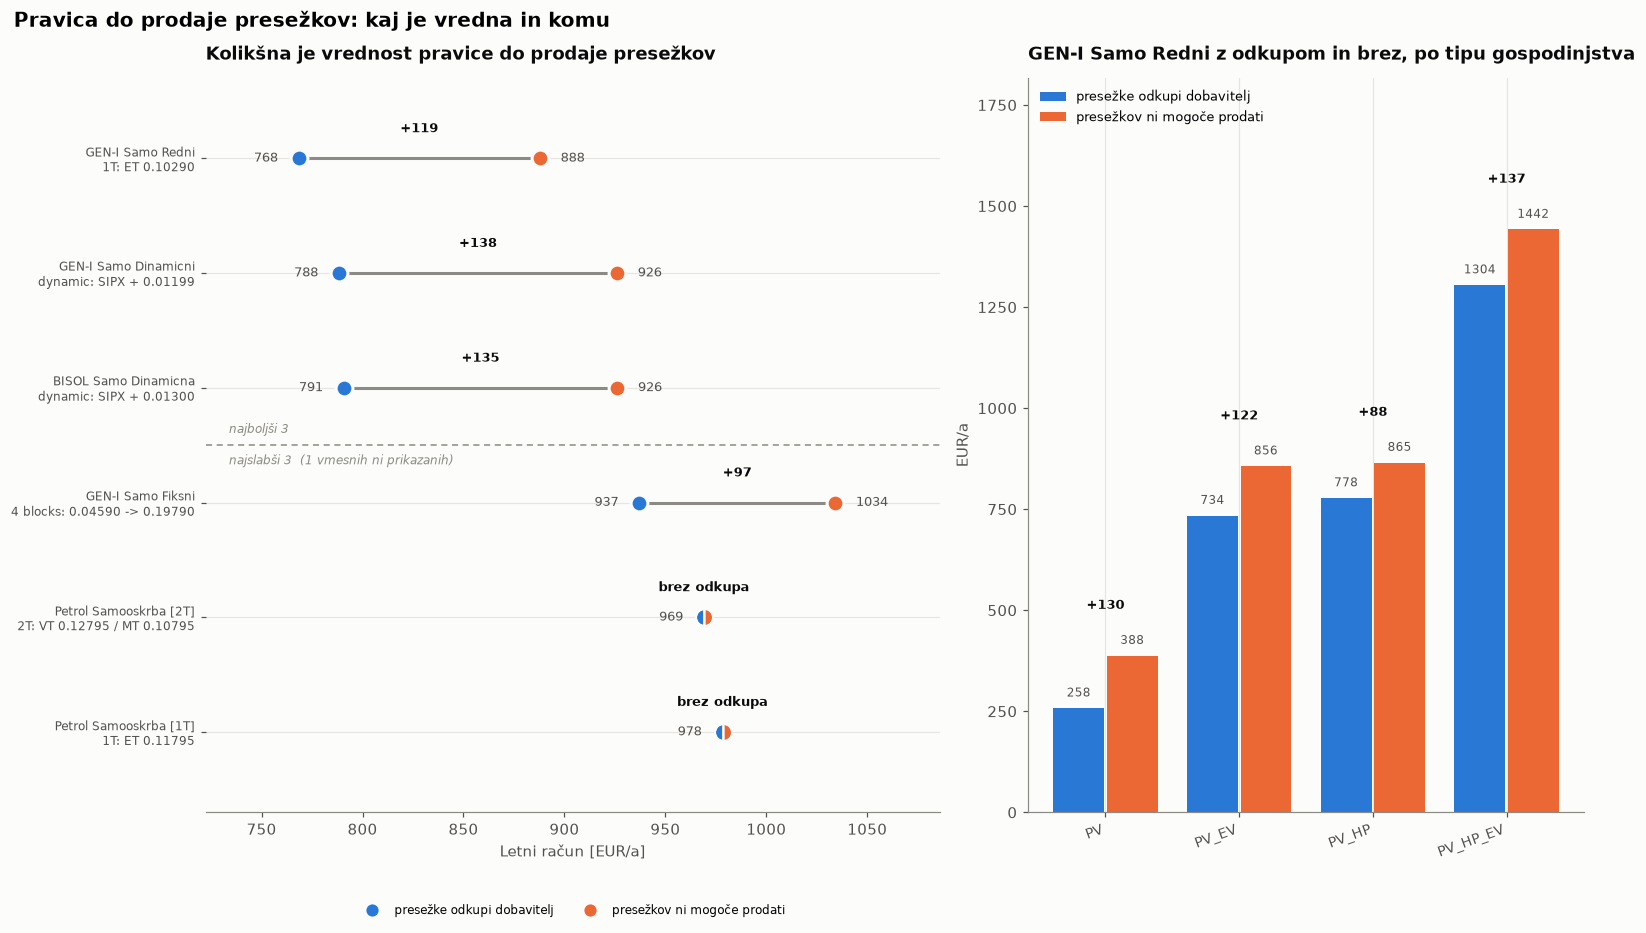

,credited,nosale,Worth_EUR,Export_kWh
Dataset,,,,
Fluvius_PV,257.6,387.6,130.0,2411.8
Fluvius_PV_EV,734.0,856.4,122.3,2269.6
Fluvius_PV_HP,777.6,865.2,87.6,1625.7
Fluvius_PV_HP_EV,1304.5,1442.0,137.5,2551.0


In [14]:
### The two contracts on the same axis: one row per contract, one dot per regime
# A dumbbell rather than paired bars. The quantity of interest is the DISTANCE
# between two states of the same household on the same contract, and a connector
# shows a difference far better than two bar lengths the eye has to subtract.
# Both dots are labelled, so identity never rests on hue alone.
fig, axes = plt.subplots(1, 2, figsize=(14.6, 2.9 + 0.95 * len(head)),
                         gridspec_kw={"width_ratios": [1.32, 1]})

ypos = np.arange(len(head))[::-1]
span = head["NoSale_EUR"].max()
for y, (opt, row) in zip(ypos, head.iterrows()):
    axes[0].plot([row["Credited_EUR"], row["NoSale_EUR"]], [y, y],
                 color=MUTED, lw=2.0, zorder=1, solid_capstyle="round")
    if row["Worth_EUR"] < 0.5:
        # A list that never bought surpluses in the first place: the two regimes
        # land on the same euro, so one dot would hide the other and read as a
        # missing series. Split the marker instead -- half each hue, on the spot
        # they share.
        for regime, side in (("credited", "left"), ("nosale", "right")):
            axes[0].plot(row["Credited_EUR"], y, marker="o", ms=11, ls="",
                         color=REGIME_COLOR[regime], fillstyle=side,
                         mec=SURFACE, mew=1.2, zorder=3)
    else:
        # 2 px surface ring on each mark so a dot never dissolves into the connector
        for value, regime in ((row["Credited_EUR"], "credited"),
                              (row["NoSale_EUR"], "nosale")):
            axes[0].plot(value, y, marker="o", ms=11, color=REGIME_COLOR[regime],
                         mec=SURFACE, mew=2.0, zorder=3)
    axes[0].text(row["Credited_EUR"] - span * 0.010, y, f"{row['Credited_EUR']:.0f}",
                 va="center", ha="right", fontsize=8.5, color=INK_2)
    if row["Worth_EUR"] >= 0.5:
        axes[0].text(row["NoSale_EUR"] + span * 0.010, y, f"{row['NoSale_EUR']:.0f}",
                     va="center", ha="left", fontsize=8.5, color=INK_2)
    axes[0].text((row["Credited_EUR"] + row["NoSale_EUR"]) / 2, y + 0.20,
                 f"+{row['Worth_EUR']:.0f}" if row["Worth_EUR"] >= 0.5 else "brez odkupa",
                 va="bottom", ha="center", fontsize=8.5, color=INK,
                 fontweight="semibold")

# The row label carries the contract, the meter variant and what it is billed
# on -- everything needed to tell two rows of the same supplier apart.
axes[0].set_yticks(ypos, [f"{short_list_name(o)}\n{head.loc[o, 'Structure']}"
                          for o in head.index], fontsize=8)
# A rule between the best block and the worst block: the middle of the ranking
# is missing, and a continuous axis would imply it is not.
if len(best) < len(head):
    axes[0].axhline(ypos[len(best) - 1] - 0.5, color=MUTED, lw=1.0, ls=(0, (4, 3)))
    axes[0].text(head["Credited_EUR"].min() * 0.955, ypos[len(best) - 1] - 0.42,
                 f"najboljši {len(best)}", va="bottom", ha="left", fontsize=8,
                 color=MUTED, style="italic")
    axes[0].text(head["Credited_EUR"].min() * 0.955, ypos[len(best) - 1] - 0.58,
                 f"najslabši {len(worst)}" + (f"  ({len(middle)} vmesnih ni prikazanih)"
                                              if middle else ""),
                 va="top", ha="left", fontsize=8, color=MUTED, style="italic")
axes[0].set_xlim(head["Credited_EUR"].min() * 0.94, span * 1.05)
axes[0].set_ylim(-0.7, len(head) - 0.3)
axes[0].set_xlabel("Letni račun [EUR/a]")
axes[0].set_title("Kolikšna je vrednost pravice do prodaje presežkov", loc="left")
axes[0].grid(axis="x")
axes[0].spines["left"].set_visible(False)
below_legend(axes[0],
             [plt.Line2D([], [], marker="o", ls="", ms=10, mec=SURFACE, mew=2.0,
                         color=REGIME_COLOR[r]) for r in ("credited", "nosale")],
             [REGIME_LABEL[r] for r in ("credited", "nosale")], ncol=2, y=-0.11)

# Per household type, on the best contract of each regime: who the buyback
# matters to. Grouped bars, hue = regime, type on the labelled axis.
best_pair = {"credited": (pv_best, df_pv), "nosale": (pv0_best, df_pv0)}
groups_pv = list(hc.PV_GROUPS)
by_group_regime = pd.DataFrame({
    regime: (frame[frame["Option"] == opt]
             .groupby("Dataset")["Cost_EUR"].mean().reindex(groups_pv))
    for regime, (opt, frame) in best_pair.items()
})
xpos = np.arange(len(groups_pv))
bar_w = 0.38
for i, regime in enumerate(("credited", "nosale")):
    axes[1].bar(xpos + (i - 0.5) * (bar_w + 0.02), by_group_regime[regime],
                width=bar_w,
                color=REGIME_COLOR[regime], label=REGIME_LABEL[regime])
    for x, v in zip(xpos + (i - 0.5) * (bar_w + 0.02), by_group_regime[regime]):
        axes[1].text(x, v + by_group_regime.to_numpy().max() * 0.015, f"{v:.0f}", ha="center",
                     va="bottom", fontsize=8, color=INK_2)
# The delta is the finding, so it is written between the pair rather than left
# for the eye to subtract two bar heights.
for x, (lo, hi) in zip(xpos, zip(by_group_regime["credited"],
                                 by_group_regime["nosale"])):
    axes[1].text(x, hi + by_group_regime.to_numpy().max() * 0.075,
                 f"+{hi - lo:.0f}", ha="center", va="bottom", fontsize=8.5,
                 color=INK, fontweight="semibold")
axes[1].set_xticks(xpos, [group_label(g) for g in groups_pv],
                   rotation=20, ha="right", fontsize=9)
axes[1].set_ylim(0, by_group_regime.to_numpy().max() * 1.26)
axes[1].set_ylabel("EUR/a")
axes[1].set_title(
    (f"{short_list_name(pv_best)} z odkupom in brez, po tipu gospodinjstva"
     if pv_best == pv0_best else
     "Na najcenejšem ceniku vsake možnosti, po tipu gospodinjstva"), loc="left")
axes[1].legend(fontsize=8.5, loc="upper left")
axes[1].grid(axis="y")

fig.suptitle("Pravica do prodaje presežkov: kaj je vredna in komu",
             fontsize=13, fontweight="semibold", x=0.012, ha="left")
fig.tight_layout()
plt.show()

by_group_regime.assign(
    Worth_EUR=lambda d: d["nosale"] - d["credited"],
    Export_kWh=df_pv.groupby("Dataset")["Export_kWh"].mean().reindex(groups_pv),
).round(1)

In [15]:
### Read-out: is the contract choice separable from the right to sell?
per_hh = (df_pv.set_index(["Dataset", "Household", "Option"])["Cost_EUR"]
          .rename("credited").to_frame()
          .join(df_pv0.set_index(["Dataset", "Household", "Option"])["Cost_EUR"]
                .rename("nosale")))
per_hh["worth"] = per_hh["nosale"] - per_hh["credited"]
best_worth = per_hh.xs(pv_best, level="Option")["worth"]
export_by_unit = df_pv.groupby(["Dataset", "Household"])["Export_kWh"].first()
rel_share = pd.DataFrame({
    "credited": df_pv[df_pv["Option"] == pv_best].groupby("Dataset")["Cost_EUR"].mean(),
    "nosale": df_pv0[df_pv0["Option"] == pv0_best].groupby("Dataset")["Cost_EUR"].mean(),
}).reindex(hc.PV_GROUPS)
rel_share["pct"] = 100.0 * (rel_share["nosale"] / rel_share["credited"] - 1.0)

lines = [f"{'contract':30s}{'billed on':30s}{'credited':>10s}{'no sale':>10s}{'worth':>9s}"]
for opt, row in head.iterrows():
    mark = "  best" if row["End"] == "best" else "  worst"
    lines.append(f"{short_list_name(opt):30s}{row['Structure']:30s}"
                 f"{row['Credited_EUR']:>10.2f}{row['NoSale_EUR']:>10.2f}"
                 f"{row['Worth_EUR']:>9.2f}{mark}")

lines += ["", ]
if reordered.empty:
    lines += [
        "The ranking is IDENTICAL under both regimes, which is the useful answer: the choice of "
        "contract and the",
        "right to sell are SEPARABLE decisions. A household can sign the cheapest import "
        "contract without knowing",
        "yet whether it will be allowed to sell, and adding a buyback later cannot make it the "
        "wrong contract.",
    ]
else:
    lines += [
        "The two rankings DISAGREE, so the decisions are ENTANGLED -- "
        + ", ".join(f"{short_list_name(o)} is #{head.loc[o, 'Rank_Credited']} credited but "
                    f"#{head.loc[o, 'Rank_NoSale']} without" for o in reordered.index) + ".",
        "A household that cannot sell its surplus should not simply sign what its neighbour "
        "with a buyback signed.",
    ]

# The metering variant, priced against the buyback on the same chart.
pairs = sorted({hc.option_base_id(o) for o in pv_summary.index
                if hc.option_variant(o) != hc.VARIANT_NA})
if pairs:
    lines += ["", "What the METER is worth, on the lists that publish both variants:"]
    for base in pairs:
        two, one = f"{base}@{hc.VARIANT_2T}", f"{base}@{hc.VARIANT_1T}"
        d2, d1 = pv_summary.loc[two, "Cost_EUR"], pv_summary.loc[one, "Cost_EUR"]
        cheaper = "2T" if d2 < d1 else "1T"
        lines.append(f"   {base:22s} 2T {d2:8.2f} vs 1T {d1:8.2f} EUR/a  -> {cheaper} is "
                     f"cheaper by {abs(d2 - d1):.2f} EUR/a")
    lines.append(f"   Against {head['Worth_EUR'].max():.0f} EUR/a for the right to sell, the "
                 f"meter is the smaller decision on this sample --")
    lines.append("   but it is the one a household can change without changing supplier.")

lines += [
    "",
    f"On {short_list_name(pv_best)} the right to sell is worth "
    f"{best_worth.mean():.0f} EUR/a on average, and it is worth a very",
    "different amount to different roofs:",
    f"   most      {best_worth.idxmax()[0]} household {best_worth.idxmax()[1]}: "
    f"{best_worth.max():.0f} EUR/a "
    f"({export_by_unit.loc[best_worth.idxmax()]:.0f} kWh/a exported)",
    f"   least     {best_worth.idxmin()[0]} household {best_worth.idxmin()[1]}: "
    f"{best_worth.min():.0f} EUR/a "
    f"({export_by_unit.loc[best_worth.idxmin()]:.0f} kWh/a exported)",
    f"   community {len(best_worth)} households together: {best_worth.sum():.0f} EUR/a, "
    f"mean {best_worth.mean():.0f}, median {best_worth.median():.0f}",
    "",
    "In absolute euros it tracks how much a roof exports, but as a SHARE of the bill it "
    "runs the other way --",
    "the smaller the household, the more of its bill the buyback is:",
    *[f"   {group_label(g):8s} {rel_share.loc[g, 'credited']:7.0f} -> "
      f"{rel_share.loc[g, 'nosale']:.0f} EUR/a, "
      f"+{rel_share.loc[g, 'pct']:.0f} % of the credited bill"
      for g in rel_share.index],
    "",
    "Read that as a ceiling, not a saving: it is the most a household should pay per year "
    "for a supplier",
    "that buys its surplus, on top of whatever that supplier charges for the import side.",
    "",
    "And the number to keep next to any battery result: on the best contract, a PV "
    "household's whole",
    f"excess-power charge -- the ONE line a battery can move on this bill -- is "
    f"{pv_summary.loc[pv_best, 'Excess_Power_EUR']:.2f} EUR/a,",
    f"against {best_worth.mean():.0f} EUR/a for the right to sell and "
    f"{pv_switch:.0f} EUR/a for picking the right contract out of {len(pv_summary)}.",
]
print("\n".join(lines))

contract                      billed on                       credited   no sale    worth
GEN-I Samo Redni              1T: ET 0.10290                    768.42    887.78   119.36  best
GEN-I Samo Dinamicni          dynamic: SIPX + 0.01199           788.37    925.99   137.62  best
BISOL Samo Dinamicna          dynamic: SIPX + 0.01300           790.73    926.11   135.38  best
GEN-I Samo Fiksni             4 blocks: 0.04590 -> 0.19790      937.12   1034.08    96.96  worst
Petrol Samooskrba [2T]        2T: VT 0.12795 / MT 0.10795       969.14    969.14     0.00  worst
Petrol Samooskrba [1T]        1T: ET 0.11795                    978.32    978.32     0.00  worst

The two rankings DISAGREE, so the decisions are ENTANGLED -- GEN-I Samo Fiksni is #5 credited but #7 without, Petrol Samooskrba [2T] is #6 credited but #4 without, Petrol Samooskrba [1T] is #7 credited but #5 without.
A household that cannot sell its surplus should not simply sign what its neighbour with a buyback signed.

What 

### What this notebook does and does not show

* **No battery, anywhere.** That is what makes every answer here a contract answer rather
  than a control answer, and it is also the limit: nothing below says what a battery is
  worth. It says what the *contract* is worth, which is the number a battery result has to
  beat before it is interesting. `MILP_horizon_comparison` and
  `Multuser_Battery_Size_Optimization` are the other half.
* **The excess-power charge is identical on every list, in every chapter**, because it is
  a network charge. It appears in all three totals so that each is a real bill, but it can
  never be a reason to prefer a contract — and it is the only line on the whole bill a
  battery can move. On the PV households it is a few euros a year against a 130 EUR/a
  buyback and a 200 EUR/a spread between lists.
* **The profiles are already netted, so self-consumption is invisible.** The Fluvius
  columns are meter registers — offtake and injection — and the roof's own consumption was
  netted away before the data was written. Every euro in chapters 2–4 is therefore about
  the *residual* import and the *residual* surplus. Chapter 3 removes the value of the
  surplus, not the value of the roof: a household that could not sell a single kWh would
  still be far better off with the roof than without it, and no table here shows that
  saving because the data cannot.
* **Interval-level netting is physical, not contractual.** Within one 15-minute interval
  the meter registers the residual whatever the contract says. What the contract decides is
  only what a *surplus* is worth, which is exactly the term chapter 3 zeroes. Routing a
  no-buyback household through `si_dobava` instead would credit its exports at the full
  retail rate including network charges and VAT — unbounded arbitrage, and not a contract
  that exists.
* **A row is a contract *and* a meter.** A *tarifni* list publishes VT/MT for a two-tariff
  meter and a single ET rate for a one-tariff meter; both are real products and the household
  picks one, so each appears as its own row tagged `[2T]` or `[1T]`, with the `Structure`
  column naming the rates. Rows with no tag have no such choice to offer — a 4-block
  (*aktivni*) or spot-linked (*dinamični*) list, or a *tarifni* list that publishes only one
  of the two. Two asymmetries matter for chapters 2–4: `GENI_SAMO_REDNI` is **1T only**,
  because GEN-I sells no two-tariff *samooskrba* product, and `PETROL_SAMOOSKRBA` is the only
  samooskrba list publishing both. The `et` field on an *aktivni* list is **not** a variant —
  it is the substitute rate for intervals with no 15-minute metering, and it is never offered
  as an alternative product, so it is correctly absent from the options.
* **The variant is priced by the pricing library, not re-derived here.** The 1T reading of a
  list is `dataclasses.replace(paket, vt=0, mt=0)`, which sends `si_obracun._cena_prevzema`
  down its ET branch and changes the supplier energy rate and nothing else — same network
  charges, same levies, same VAT, same fixed items. The variant is passed to
  `calculate_interval_price` as an object rather than registered in `PAKETI`, so no other
  notebook sees a catalogue that grew rows.
* **Three of the six samooskrba lists share a supplier and two share a tariff structure.**
  `GENI_SAMO_AKTIVNI` and `GENI_SAMO_FIKSNI` are both 4-block lists differing mainly in
  buyback, which is why they finish next to each other in both rankings. The comparison is
  a comparison of *catalogued products*, not of tariff structures in the abstract: a
  different set of suppliers would move the ranking without changing any mechanism.
* **`PER_GROUP` changes the sample, not the method.** It is the households drawn from each of
  the 8 Fluvius groups, so the panel stays balanced at any setting and the group mix never
  moves. Every comparison stamps its own `Per_Group` on every row and each chapter refuses a
  cache written at another setting, so the only thing a lower `PER_GROUP` costs is precision —
  the per-household spreads (`worst household [%]`, the best/worst call-outs) are the figures
  that move most, since they are order statistics over a smaller sample.
* **`Delta_pct` is measured per household, then averaged.** An option is never flattered by a
  household mix that suits it, and `Worst_Delta_pct` reports the single household it treats
  worst — a number no mean would show.
* **The agreed power is a policy, not an optimum.** Every chapter models a household that
  agrees exactly last month's per-block peak. Agreeing *less* in the expensive block 1 and
  paying the 1.05-weighted exceedance can be cheaper; that is a separate question, and what
  matters here is that the policy is identical for every household, every list and every
  chapter, so it cannot move a comparison. `MILP_horizon_comparison` section 1b has the
  argument and the alternatives.
* **A household that never touches its assigned agreed power is exempt from the
  excess-power charge** (since 24. 4. 2025, up to 43 kW). The households here manage the
  figure themselves and so pay it. A household choosing the exemption instead would read
  every table with the excess-power column removed — which, since that column is identical
  across lists, changes no ranking and no delta.
* **NET metering is absent on purpose.** It is closed to new consents and settles once a
  year rather than per interval, so it is neither a list a household can choose into nor a
  bill this evaluator can write. See `Multuser_Battery_Size_Optimization` for it as a
  legacy reference line for the households that still hold it.
* **One year, one price regime, 2026 rules.** The supplier rates are the catalogued ones at
  the dates in `si_paketi`, the network tariff and the 1.05 exceedance weighting are the
  2026 values (0.9 through 2025, 1.20 from 2028), and the SIPX series is 2024's. A dynamic
  list's standing next to a flat one is a claim about *that* market year, and the dynamic
  lists are the ones that would move most in another.